# **TAS (Tele Assistance System) Dimensional Analysis Modelling**
NOTE: _[DASA CASE STUDY 1]_

## **Summary**

This notebook is focused on three main objectives:
1. summarizing the key aspects of the Tele Assistance System (TAS) architecture and its adaptive capabilities in the context of telehealth services for chronic patients.
2. Modelling the TAS architecture using appropriate design notations and tools to visualize its components and interactions.
3. Simulating the TAS behavior under different scenarios to evaluate its performance and adaptability with Queue Network (QN) models.

The results will be used to evaluate the Dimensional Analysis for Software Architecture (DASA) methodology, its software tool (PyDASA) and its effectiveness in modelling and Quality Scenarios (QS) trade-off in self-adaptive-systems (SAS).

---

## **Software Architecture**
- TAS (Tele Assistance System) operates in a dynamic environment where service quality, availability, and user needs frequently change.
- The TAS is further subdivided into Controller and Target System subsystem components.
- The Controller is responsible for managing the overall system behavior, while the Target System focuses on executing specific tasks related to patient care.
- The TAS target systems follows a Service-oriented architecture (SOA) pattern.
- The TAS Controller follows a MAPE-K (Monitor-Analyze-Plan-Execute-Knowledge) feedback loop for self-adaptation.
- Adaptations focus on maintaining **reliability**, **performance**, and **compliance** with patient care standards (5 specific scenarios).
- ActivFORMS provides the runtime framework for model-based adaptation using runtime models, simulations, and verified decision-making.

---

_**NOTE: MORE DETAILS ON THE ARCHITECTURE IN THE ANALYTICAL MODELLING NOTEBOOK!.**_

---

## **Code**

_**SUMMARY:**_

This code is for the analytical solution of the Case Study (TAS) Dimensional Analysis Model and is structured as follows:
1. Analytical Dimensional Model (DA).
2. Importing necessary libraries and modules.
3. Loading DA default configuration.
4. Solving the DA analytically.
5. Solving the DA with Monte Carlo simulations.
6. Plotting the DA with the obtained metrics.
7. Loading DA 'optimal' configuration.
8. Solving the DA optimally.
9. Simulating the DA with the 'optimal' configuration.
10. Plotting the optimal DA with the obtained metrics.
11. Saving the results.
12. Comparing the analytical results (Default Vs. Optimal)
13. Visualizing the results.
14. Generating a summary report.

## **Target System Queue Network Model**

<svg viewBox="0 0 4650 2000" width="1400" height="650">
    <!-- SVG content -->
    <image href="assets/cs1/img/04A - Queue Network.svg" alt="queue-net-diagram" />
    <div align="center"><em>Image 4. TAS Queue Network Diagram.</em></div>
</svg>

### **Necessary Imports**

In [1]:
# -*- coding: utf-8 -*-
# Native imports
import os
import re
import sys
import time
import gc
from typing import Union

# Third-party imports
import numpy as np
import pandas as pd

# import data analysis + regression models packages
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings

# import queue network + models packages
from src.model.queueing import Queue
from src.model.analytical import solve_jackson_network, calculate_net_metrics

# import plot functions + grahics
from src.view.plots import plot_queue_network
from src.view.plots import plot_net_comparison
from src.view.plots import plot_net_difference
from src.view.plots import plot_nodes_heatmap
from src.view.plots import plot_coef_histograms

In [2]:
# cleaning memory
gc.collect()

20

### **Function Definitions**

In [3]:
# Simple formatter for console output

def fmt(val: Union[int, float, np.number]) -> Union[str, np.ndarray]:
    """Format a number to 4 decimal places for console output.

    Args:
        val (Union[int, float, np.number, np.ndarray]): The value to format.

    Returns:
        Union[str, np.ndarray]: The formatted value as a string or an array of strings.
    """
    if isinstance(val, (int, float, np.number)):
        if np.isnan(val) or np.isinf(val):
            return str(val)
        return f"{val:.4f}"
    elif isinstance(val, np.ndarray):
        return np.array([fmt(x) for x in val])
    return val

In [4]:
# Load configuration from a CSV file
def load(path: str, fname: str) -> pd.DataFrame:
    """Load configuration from a CSV file.

    Args:
        path (str): The directory path where the CSV file is located.
        fname (str): The name of the CSV file to load.

    Returns:
        pd.DataFrame: A DataFrame containing the configuration data.
            CSV format:
                - node: <node_id>
                - miu: <mean_service_time>
                - c: <service_channels>
                - K: <buffer_capacity | max_queue_length>
                - lambda0: <initial_arrival_rate>
                - L0: <initial_queue_length>
                - pm: <matrix_routing_probabilities>
    """
    # path = os.path.dirname(__file__)
    _file_path = os.path.join(path, fname)
    print(f"Loading configuration from: {_file_path}")
    df = pd.read_csv(_file_path)
    return df

In [5]:
# save dataframes in CSV files
def save(path: str, fname: str, data: pd.DataFrame) -> None:
    """Save a DataFrame to a CSV file.

    Args:
        path (str): The directory path where the CSV file will be saved.
        fname (str): The name of the CSV file to save.
        data (pd.DataFrame): The DataFrame containing the data to save.
    """
    # path = os.path.dirname(__file__)
    _file_path = os.path.join(path, fname)
    print(f"Saving data to: {_file_path}")
    data.to_csv(_file_path, index=False)

In [6]:
# DEFINE REGRESSION MODELS

# 1. Linear Model: S = β₀ + β₁·O + β₂·η
def linear_model(X, beta0, beta1, beta2):
    """Linear: S = β₀ + β₁·O + β₂·η"""
    O, eta = X
    return beta0 + beta1 * O + beta2 * eta


# 2. Log-Linear Model: log(S) = β₀ + β₁·O + β₂·η
def log_linear_predict(X, beta0, beta1, beta2):
    """Log-Linear: S = exp(β₀ + β₁·O + β₂·η)"""
    O, eta = X
    return np.exp(beta0 + beta1 * O + beta2 * eta)


# 3. Power-Law Model: S = A · O^B · η^C
def power_law_model(X, A, B, C):
    """Power-Law: S = A · O^B · η^C"""
    O, eta = X
    O_safe = np.maximum(O, 1e-10)
    eta_safe = np.maximum(np.abs(eta), 1e-10)
    return A * np.power(O_safe, B) * np.power(eta_safe, C)


# 4. Exponential Model: S = A · exp(B·O + C·η)
def exponential_model(X, A, B, C):
    """Exponential: S = A · exp(B·O + C·η)"""
    O, eta = X
    exponent = B * O + C * eta
    exponent = np.clip(exponent, -50, 50)  # Prevent overflow
    return A * np.exp(exponent)


# 5. Weibull-like Model: S = A · [1 - exp(-(B·O + C·η)^k)]
def weibull_model(X, A, B, C, k):
    """Weibull-like: S = A · [1 - exp(-(B·O + C·η)^k)]"""
    O, eta = X
    linear_part = B * O + C * eta
    linear_part = np.maximum(linear_part, 0)
    power_part = np.power(linear_part, k)
    power_part = np.clip(power_part, 0, 50)  # Prevent overflow
    return A * (1 - np.exp(-power_part))


# 6. Gamma-like Model: S = A · (B·O + C·η + ε)^k
def gamma_model(X, A, B, C, k):
    """Gamma-like: S = A · (B·O + C·η + ε)^k"""
    O, eta = X
    linear_part = B * O + C * eta + 0.01
    linear_part = np.maximum(linear_part, 0.01)
    return A * np.power(linear_part, k)


# 7. Logistic Model: S = L / (1 + exp(-k·(B·O + C·η - x₀)))
def logistic_model(X, L, k, B, C, x0):
    """Logistic: S = L / (1 + exp(-k·(B·O + C·η - x₀)))"""
    O, eta = X
    z = k * (B * O + C * eta - x0)
    z = np.clip(z, -50, 50)  # Prevent overflow
    return L / (1 + np.exp(-z))

In [7]:
# path = os.path.dirname(__file__)\
PATH = os.getcwd()
print(f"Notebook path: {PATH}")

Notebook path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies


In [8]:
# Folder names
asset_folder = "assets"
docs_folder = "docs"
img_folder = "img"
data_folder = "data"
report_folder = "reports"
results_folder = "results"
analysis_folder = "analysis"
cs_folder = "cs1"

In [9]:
# setting case study data folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")

Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data


In [10]:
# load monte carlo simulation experimental data
dflt_fname = "dflt_dimensional_net_coeffs.csv"
dflt_sys_coef = load(file_path, dflt_fname)
dflt_sys_coef.info()

Loading configuration from: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\dflt_dimensional_net_coeffs.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65000 entries, 0 to 64999
Data columns (total 11 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}      65000 non-null  float64
 1   \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}            65000 non-null  float64
 2   \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}           65000 non-null  float64
 3   \Pi_{4}=\frac{K_{TAS}}{c_{TAS}}                    65000 non-null  float64
 4   \Pi_{5}=\frac{L_{TAS}}{c_{TAS}}                    65000 non-null  float64
 5   O=\Pi_{Occ}=\frac{L}{K}                            65000 non-null  float64
 6   \eta=\Pi_{Eff}=\frac{\chi}{\mu}                    65000 non-null  float64
 7   S=\Pi_{Sta

In [11]:
print("--- Dimensionless Coefficients Analysis Preparations ---")

# coefficients dictionary for column names
occ_coef = f"O=\\Pi_{{Occ}}=\\frac{{L}}{{K}}"
eff_coef = f"\\eta=\\Pi_{{Eff}}=\\frac{{\\chi}}{{\\mu}}"
stall_coef = f"S=\\Pi_{{Stall}}=\\ln\\left(\\frac{{\\lambda*W}}{{K}}\\right)"

# column list
deriv_cols = [occ_coef, eff_coef, stall_coef]
print(f"Derived Coefficient columns: {deriv_cols}")

--- Dimensionless Coefficients Analysis Preparations ---
Derived Coefficient columns: ['O=\\Pi_{Occ}=\\frac{L}{K}', '\\eta=\\Pi_{Eff}=\\frac{\\chi}{\\mu}', 'S=\\Pi_{Stall}=\\ln\\left(\\frac{\\lambda*W}{K}\\right)']


In [12]:
print("--- Adjusting Coefficients ---")
log_occ_coef = f"O=\\Pi_{{Occ}}=\\ln\\left(\\frac{{L}}{{K}}\\right)"
log_eff_coef = f"\\eta=\\Pi_{{Eff}}=\ln\\left(\\frac{{\\chi}}{{\\mu}}\\right)"

adjust_dict = {
    occ_coef: log_occ_coef,
    eff_coef: log_eff_coef
}

for coef in adjust_dict:
    if coef in dflt_sys_coef.columns.tolist():
        old = dflt_sys_coef[coef].copy()
        dflt_sys_coef[coef] = np.log(dflt_sys_coef[coef] + 1e-6)
        # dflt_sys_coef[coef] = np.log1p(dflt_sys_coef[coef])
        # dflt_sys_coef[coef] = dflt_sys_coef[coef]
        diff = old - dflt_sys_coef[coef]
        diff = abs(diff)
        print(f"\tdiff: {diff.sum()/len(dflt_sys_coef):.6f}")

# rename adjusted columns
dflt_sys_coef = dflt_sys_coef.rename(columns=adjust_dict)
dflt_sys_coef.info()

--- Adjusting Coefficients ---
	diff: 3.181849
	diff: 1.921008
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65000 entries, 0 to 64999
Data columns (total 11 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}      65000 non-null  float64
 1   \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}            65000 non-null  float64
 2   \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}           65000 non-null  float64
 3   \Pi_{4}=\frac{K_{TAS}}{c_{TAS}}                    65000 non-null  float64
 4   \Pi_{5}=\frac{L_{TAS}}{c_{TAS}}                    65000 non-null  float64
 5   O=\Pi_{Occ}=\ln\left(\frac{L}{K}\right)            65000 non-null  float64
 6   \eta=\Pi_{Eff}=\ln\left(\frac{\chi}{\mu}\right)    65000 non-null  float64
 7   S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right)  65000 non-null  float64
 8   \Pi_{Occ}              

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Felipe\AppData\Local\Temp\ipykernel_5168\3455479423.py:3: SyntaxWarning: invalid escape sequence '\l'
  log_eff_coef = f"\\eta=\\Pi_{{Eff}}=\ln\\left(\\frac{{\\chi}}{{\\mu}}\\right)"


In [13]:
print("--- Cleaning Invalid Values from Plot Data ---")
# clear plot data
LIM_FLOW = 1.0
LIM_BUFFER = 1.0

# clear x-axis: occ < 1.0
print(f"cleaning invalid values in: {log_occ_coef}")
dflt_sys_coef = dflt_sys_coef[dflt_sys_coef[log_occ_coef] < LIM_BUFFER]
print(f"Plot data with {log_occ_coef} < {LIM_BUFFER}: {dflt_sys_coef.shape}")

# y-axis: eta < 1.0
print(f"cleaning invalid values in: {log_eff_coef}")
dflt_sys_coef = dflt_sys_coef[dflt_sys_coef[log_eff_coef] < LIM_FLOW]
print(f"Plot data with {log_eff_coef} < {LIM_FLOW}: {dflt_sys_coef.shape}")
dflt_sys_coef.info()

--- Cleaning Invalid Values from Plot Data ---
cleaning invalid values in: O=\Pi_{Occ}=\ln\left(\frac{L}{K}\right)
Plot data with O=\Pi_{Occ}=\ln\left(\frac{L}{K}\right) < 1.0: (64950, 11)
cleaning invalid values in: \eta=\Pi_{Eff}=\ln\left(\frac{\chi}{\mu}\right)
Plot data with \eta=\Pi_{Eff}=\ln\left(\frac{\chi}{\mu}\right) < 1.0: (63606, 11)
<class 'pandas.core.frame.DataFrame'>
Index: 63606 entries, 1 to 64999
Data columns (total 11 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}      63606 non-null  float64
 1   \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}            63606 non-null  float64
 2   \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}           63606 non-null  float64
 3   \Pi_{4}=\frac{K_{TAS}}{c_{TAS}}                    63606 non-null  float64
 4   \Pi_{5}=\frac{L_{TAS}}{c_{TAS}}                    63606 non-nul

--- Checking Coefficient Histograms ---
	Plotting Histogram 1/3: O=\Pi_{Occ}=\ln\left(\frac{L}{K}\right)
	Plotting Histogram 2/3: \eta=\Pi_{Eff}=\ln\left(\frac{\chi}{\mu}\right)
	Plotting Histogram 3/3: S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right)


c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\src\view\plots.py:1681: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


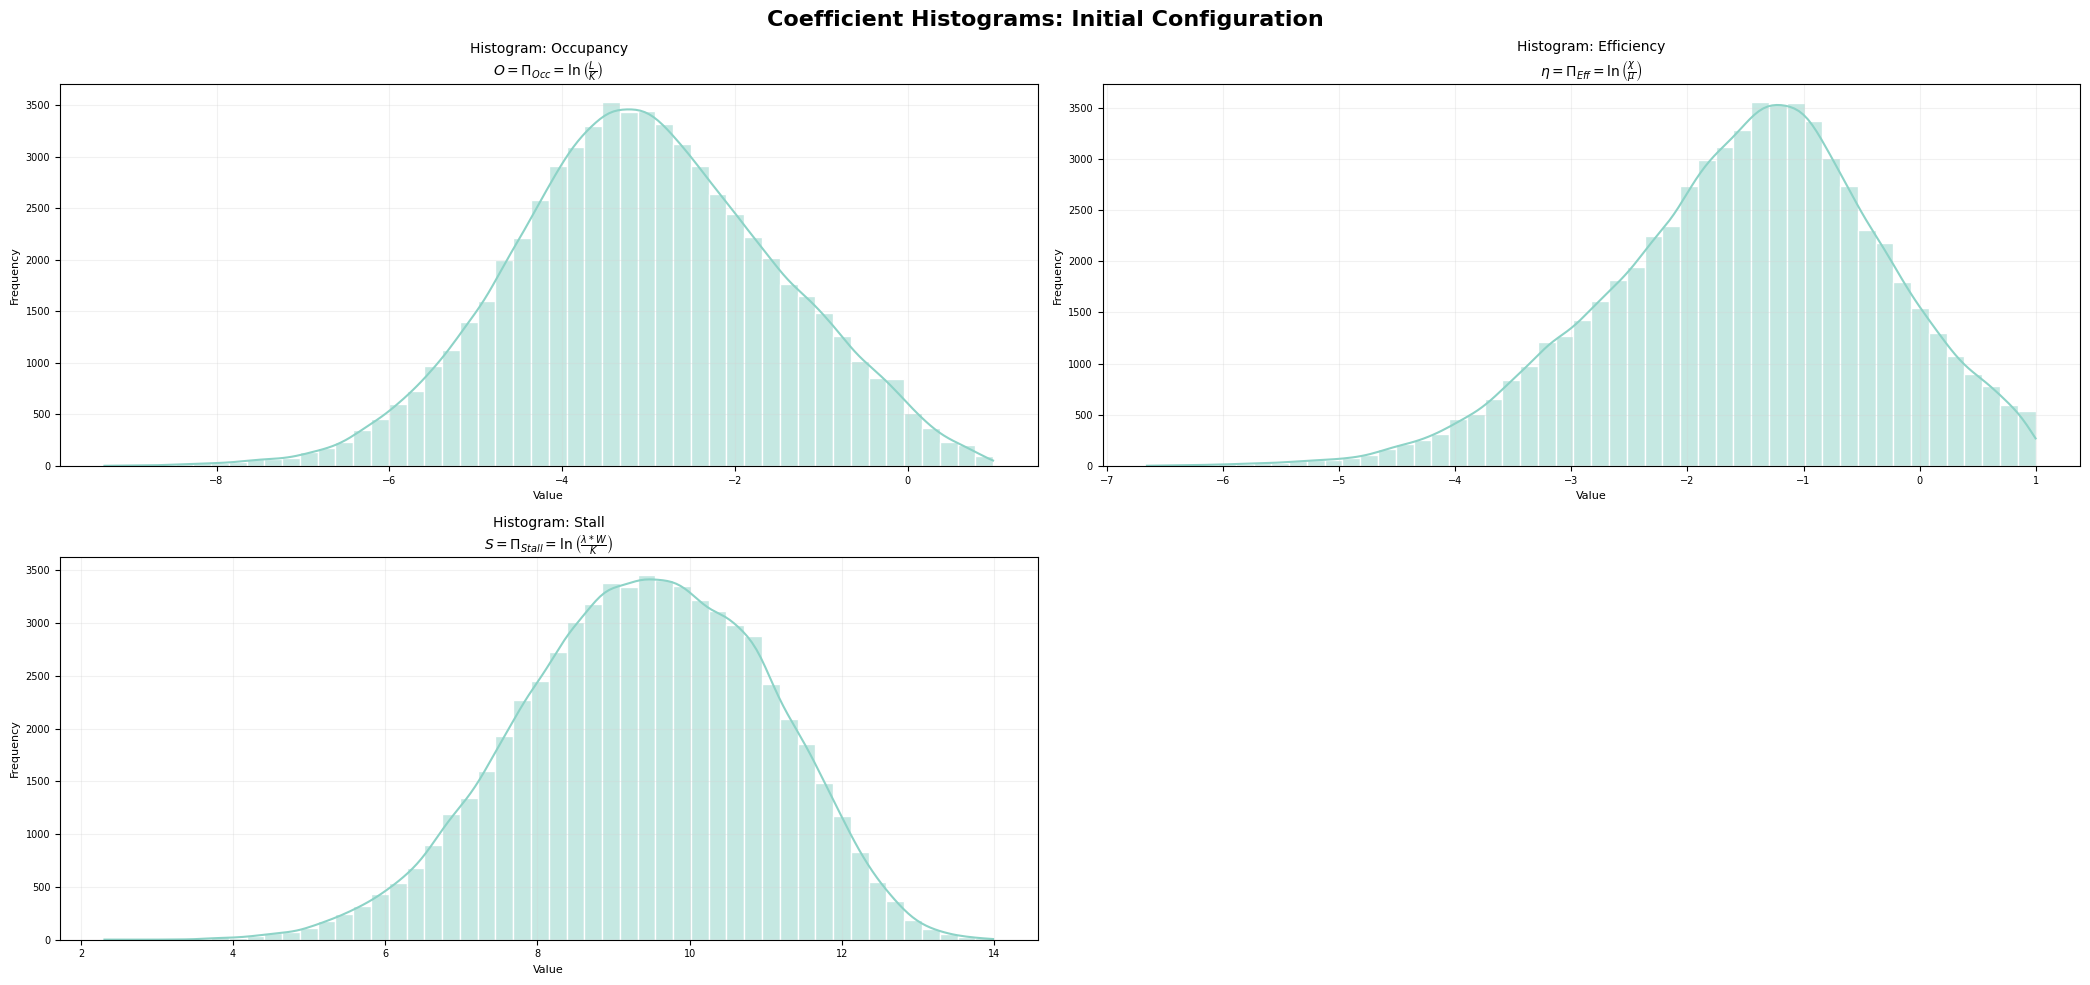

In [14]:
print("--- Checking Coefficient Histograms ---")
metrics = list(adjust_dict.values()) + [stall_coef]
labels = [
    "Occupancy",
    "Efficiency",
    "Stall",
]

plot_coef_histograms(dflt_sys_coef,
                     2,
                     metrics,
                     labels,
                     "Coefficient Histograms: Initial Configuration",
                     verbose=True)

In [15]:
# Create DataFrame from data analysis
data_df = pd.DataFrame(dflt_sys_coef[metrics])
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63606 entries, 1 to 64999
Data columns (total 3 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   O=\Pi_{Occ}=\ln\left(\frac{L}{K}\right)            63606 non-null  float64
 1   \eta=\Pi_{Eff}=\ln\left(\frac{\chi}{\mu}\right)    63606 non-null  float64
 2   S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right)  63606 non-null  float64
dtypes: float64(3)
memory usage: 1.9 MB


In [16]:
print("="*80)
print("HIGH-PERFORMANCE STALL PREDICTION MODEL (Target R² > 0.75)")
print("Strategy: Regime Detection + Feature Engineering + Ensemble")
print("="*80)

import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.mixture import GaussianMixture
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import Ridge

warnings.filterwarnings('ignore')

# ============================================================================
# STEP 1: IDENTIFY OPERATING REGIMES (Bimodal Stall Distribution)
# ============================================================================
print("\n--- Step 1: Regime Detection ---")

# Extract base features
O = data_df[log_occ_coef].values
eta = data_df[log_eff_coef].values
S = data_df[stall_coef].values

# Remove invalid values
mask = np.isfinite(O) & np.isfinite(eta) & np.isfinite(S)
O, eta, S = O[mask], eta[mask], S[mask]

# Fit GMM to detect regimes in Stall distribution
gmm = GaussianMixture(n_components=2, random_state=42)
regimes = gmm.fit_predict(S.reshape(-1, 1))

print(f"Regime 0 (Low Stall):  {np.sum(regimes == 0)} samples (mean S = {S[regimes==0].mean():.2f})")
print(f"Regime 1 (High Stall): {np.sum(regimes == 1)} samples (mean S = {S[regimes==1].mean():.2f})")

# ============================================================================
# STEP 2: ADVANCED FEATURE ENGINEERING
# ============================================================================
print("\n--- Step 2: Feature Engineering ---")

# Create comprehensive feature set
features = pd.DataFrame({
    # Original log-transformed features
    'O_log': O,
    'eta_log': eta,
    
    # # Regime indicator
    # 'regime': regimes.astype(float),
    
    # Polynomial features
    'O_sq': O**2,
    'eta_sq': eta**2,
    'O_cube': O**3,
    'eta_cube': eta**3,
    
    # Interaction terms
    'O_eta': O * eta,
    'O_eta_sq': O * eta**2,
    'O_sq_eta': O**2 * eta,
    'O_sq_eta_sq': O**2 * eta**2,

    # Inverse Interaction terms
    'O_eta_inv': 1 / (O * eta + 1e-6),
    'O_eta_sq_inv': 1 / (O * eta**2 + 1e-6),
    'O_sq_eta_inv': 1 / (O**2 * eta + 1e-6),
    'O_sq_eta_sq_inv': 1 / (O**2 * eta**2 + 1e-6),


    # Exponential features (capped for stability)
    'exp_O': np.exp(np.clip(O, -10, 2)),
    'exp_eta': np.exp(np.clip(eta, -10, 2)),
    'exp_O_eta': np.exp(np.clip(O + eta, -10, 2)),
    
    # Queue theory inspired features
    'O_over_eta': O / (1 - eta + 1e-6),
    'eta_over_O': eta / (1 - O + 1e-6),
    'O_minus_eta': O - eta,
    'abs_O_minus_eta': np.abs(O - eta),
    
    # Reciprocal features
    'inv_O': 1 / (np.abs(O) + 1e-6),
    'inv_eta': 1 / (np.abs(eta) + 1e-6),
    
    # # Regime-specific features
    # 'O_regime': O * regimes,
    # 'eta_regime': eta * regimes,
    
    # Statistical features (rolling if data has temporal structure)
    'O_eta_product': O * eta,
    'O_eta_sum': O + eta,
    'O_eta_diff_sq': (O - eta)**2,
})

print(f"Created {features.shape[1]} features from 2 base variables")
print(f"Sample size: {len(S)}")

# ============================================================================
# STEP 3: HANDLE BIMODAL TARGET DISTRIBUTION
# ============================================================================
print("\n--- Step 3: Target Transformation ---")

# Apply Yeo-Johnson transformation for bimodal distribution
pt = PowerTransformer(method='yeo-johnson')
S_transformed = pt.fit_transform(S.reshape(-1, 1)).ravel()

print(f"Original Stall range: [{S.min():.3f}, {S.max():.3f}]")
print(f"Transformed range: [{S_transformed.min():.3f}, {S_transformed.max():.3f}]")
print(f"Original skewness: {pd.Series(S).skew():.3f}")
print(f"Transformed skewness: {pd.Series(S_transformed).skew():.3f}")

# ============================================================================
# STEP 4: ROBUST FEATURE SCALING
# ============================================================================
print("\n--- Step 4: Feature Scaling ---")

scaler = RobustScaler()  # Less sensitive to outliers than StandardScaler
features_scaled = pd.DataFrame(
    scaler.fit_transform(features),
    columns=features.columns
)

# ============================================================================
# STEP 5: TRAIN-TEST SPLIT (Stratified by Regime)
# ============================================================================
X_train, X_test, y_train, y_test, regime_train, regime_test = train_test_split(
    features_scaled, S_transformed, regimes, 
    test_size=0.2, 
    random_state=42,
    stratify=regimes  # Ensure both regimes represented in train/test
)

print(f"\nTrain set: {len(X_train)} samples")
print(f"  Regime 0: {np.sum(regime_train == 0)} | Regime 1: {np.sum(regime_train == 1)}")
print(f"Test set: {len(X_test)} samples")
print(f"  Regime 0: {np.sum(regime_test == 0)} | Regime 1: {np.sum(regime_test == 1)}")

# ============================================================================
# STEP 6: STACKING ENSEMBLE WITH OPTIMIZED BASE MODELS
# ============================================================================
print("\n--- Step 6: Stacking Ensemble Training ---")

# Define base models with tuned hyperparameters
base_models = [
    ('xgb', xgb.XGBRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=2,
        gamma=0.05,
        reg_alpha=0.1,
        reg_lambda=1.5,
        random_state=42,
        n_jobs=-1
    )),
    
    ('lgb', lgb.LGBMRegressor(
        n_estimators=500,
        max_depth=9,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=15,
        reg_alpha=0.15,
        reg_lambda=1.5,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    )),
    
    ('gb', GradientBoostingRegressor(
        n_estimators=500,
        max_depth=7,
        learning_rate=0.03,
        subsample=0.85,
        min_samples_split=8,
        min_samples_leaf=4,
        max_features='sqrt',
        random_state=42
    ))
]

# Meta-learner with regularization
meta_model = Ridge(alpha=10.0)

# Create stacking ensemble
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

print("Training stacking ensemble...")
stacking_model.fit(X_train, y_train)

# ============================================================================
# STEP 7: COMPREHENSIVE EVALUATION
# ============================================================================
print("\n" + "="*80)
print("MODEL PERFORMANCE EVALUATION")
print("="*80)

# Predictions
y_train_pred_transformed = stacking_model.predict(X_train)
y_test_pred_transformed = stacking_model.predict(X_test)

# Inverse transform to original scale
y_train_pred = pt.inverse_transform(y_train_pred_transformed.reshape(-1, 1)).ravel()
y_test_pred = pt.inverse_transform(y_test_pred_transformed.reshape(-1, 1)).ravel()
y_train_orig = pt.inverse_transform(y_train.reshape(-1, 1)).ravel()
y_test_orig = pt.inverse_transform(y_test.reshape(-1, 1)).ravel()

# Calculate metrics
r2_train = r2_score(y_train_orig, y_train_pred)
r2_test = r2_score(y_test_orig, y_test_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_orig, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test_orig, y_test_pred))
mae_train = mean_absolute_error(y_train_orig, y_train_pred)
mae_test = mean_absolute_error(y_test_orig, y_test_pred)

# Cross-validation
cv_scores = cross_val_score(
    stacking_model, 
    features_scaled, 
    S_transformed, 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)

print(f"\n{'Metric':<20} {'Train':>12} {'Test':>12}")
print("-" * 45)
print(f"{'R²':<20} {r2_train:>12.6f} {r2_test:>12.6f}")
print(f"{'RMSE':<20} {rmse_train:>12.6f} {rmse_test:>12.6f}")
print(f"{'MAE':<20} {mae_train:>12.6f} {mae_test:>12.6f}")
print(f"{'Overfit (R² diff)':<20} {'':<12} {r2_train - r2_test:>12.6f}")
print("\n" + "-" * 45)
print(f"{'CV R² (5-fold)':<20} {cv_scores.mean():>12.6f} ± {cv_scores.std():.6f}")

# Success check
if r2_test > 0.75:
    print(f"\n{'='*80}")
    print(f"✅ SUCCESS! Target R² > 0.75 achieved!")
    print(f"   Test R²: {r2_test:.4f}")
    print(f"{'='*80}")
else:
    print(f"\n{'='*80}")
    print(f"⚠️  Close! Test R²: {r2_test:.4f} (Target: 0.75)")
    print(f"   Suggestions: Try deeper models or more interaction features")
    print(f"{'='*80}")

# ============================================================================
# STEP 8: REGIME-SPECIFIC PERFORMANCE
# ============================================================================
print("\n--- Regime-Specific Performance ---")

for regime_id in [0, 1]:
    mask_regime = regime_test == regime_id
    if np.sum(mask_regime) > 0:
        r2_regime = r2_score(y_test_orig[mask_regime], y_test_pred[mask_regime])
        rmse_regime = np.sqrt(mean_squared_error(y_test_orig[mask_regime], y_test_pred[mask_regime]))
        
        print(f"\nRegime {regime_id} ({'Low Stall' if regime_id == 0 else 'High Stall'}):")
        print(f"  Samples:  {np.sum(mask_regime)}")
        print(f"  R²:       {r2_regime:.4f}")
        print(f"  RMSE:     {rmse_regime:.4f}")

# ============================================================================
# STEP 9: FEATURE IMPORTANCE ANALYSIS
# ============================================================================
print("\n--- Top 15 Most Important Features ---")

# Get feature importance from XGBoost (first base model)
xgb_model = stacking_model.estimators_[0]
importances = pd.DataFrame({
    'Feature': features.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

print(importances.to_string(index=False))

# ============================================================================
# STEP 10: SAVE RESULTS
# ============================================================================
results_summary = pd.DataFrame({
    'Metric': ['Train R²', 'Test R²', 'Train RMSE', 'Test RMSE', 'CV R²', 'CV Std'],
    'Value': [r2_train, r2_test, rmse_train, rmse_test, cv_scores.mean(), cv_scores.std()]
})

save(file_path, "high_performance_stall_model_results.csv", results_summary)
print(f"\n✓ Results saved to: {file_path}/high_performance_stall_model_results.csv")

# Save feature importance
importances.to_csv(os.path.join(file_path, "feature_importance.csv"), index=False)
print(f"✓ Feature importance saved")

print(f"\n{'='*80}")
print("HIGH-PERFORMANCE MODEL TRAINING COMPLETE")
print(f"{'='*80}\n")

HIGH-PERFORMANCE STALL PREDICTION MODEL (Target R² > 0.75)
Strategy: Regime Detection + Feature Engineering + Ensemble

--- Step 1: Regime Detection ---
Regime 0 (Low Stall):  29537 samples (mean S = 7.97)
Regime 1 (High Stall): 34069 samples (mean S = 10.60)

--- Step 2: Feature Engineering ---
Created 26 features from 2 base variables
Sample size: 63606

--- Step 3: Target Transformation ---
Original Stall range: [2.310, 13.988]
Transformed range: [-3.622, 3.133]
Original skewness: -0.225
Transformed skewness: -0.032

--- Step 4: Feature Scaling ---

Train set: 50884 samples
  Regime 0: 23629 | Regime 1: 27255
Test set: 12722 samples
  Regime 0: 5908 | Regime 1: 6814

--- Step 6: Stacking Ensemble Training ---
Training stacking ensemble...

MODEL PERFORMANCE EVALUATION

Metric                      Train         Test
---------------------------------------------
R²                       0.053525     0.014993
RMSE                     1.569998     1.598209
MAE                      1.272

In [17]:
a =

SyntaxError: invalid syntax (905710932.py, line 1)

In [ ]:
np.logit()

In [ ]:
print("--- Preparing Data for Hypothesis Testing ---")
warnings.filterwarnings("ignore")

# ============================================================================
# ===================== PREPARE DATA FOR HYPOTHESIS ==========================
# ============================================================================

# Extract features (Occ, Eff) and target (Stall)
available_cols = list(adjust_dict.values())
stall_col = f"S=\\Pi_{{Stall}}=\\ln(\\frac{{\\lambda*W}}{{K}})"
print(f"\nTarget (y): {stall_coef}")

print(f"Features (X): {available_cols}")
X_data = data_df[available_cols].values
y_data = data_df[stall_coef].values

# Clean data in numpy
mask = (
    np.isfinite(X_data).all(axis=1) &
    np.isfinite(y_data) &
    (y_data > 0) # &
    # (np.log1p(dflt_sys_coef[available_cols[0]]) < 1.0) &    # Occupancy < 1
    # (dflt_sys_coef[available_cols[1]] < 1.0)                # Efficiency < 1
)

# masked data
X = X_data[mask]
y = y_data[mask]
print(X.shape, y.shape)

print(f"\nCleaned Data: {len(y)} samples")
for i in range(X.shape[1]):
    _msg = f"\tIdx-{i+1}: {available_cols[i]}"
    _msg += f" = [{X[:, i].min():.6f}, {X[:, i].max():.6f}]"
    print(_msg)

print(f"Stall (S): [{y.min():.6f}, {y.max():.6f}]")

In [ ]:
# Fit the linear model in log–log space
model = LinearRegression()
model.fit(X, y)

# Extract coefficients
alpha = model.intercept_
beta, gamma = model.coef_

print(
    f"Model: ln(S) = {alpha:.4f} + {beta:.4f}·ln(O) - {abs(gamma):.4f}·ln(η)")

In [ ]:
import matplotlib.pyplot as plt
# Predict log(S) and back-transform
data_df["S_{pred}"] = np.exp(model.predict(X))

# Calculate R² for performance
r2 = model.score(X, y)
print(f"R² = {r2:.4f}")



In [ ]:
# Quick comparison plot

plt.figure(figsize=(6, 4))
plt.scatter(data_df[stall_coef], data_df["S_{pred}"], s=10, alpha=0.4)
plt.xlabel('Observed Stall S')
plt.ylabel('Predicted Stall Ŝ')
plt.title('Observed vs Predicted Stall Coefficient')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

model_nl = GradientBoostingRegressor(n_estimators=200,
                                     learning_rate=0.05,verbose=0)
model_nl.fit(X, y)

In [ ]:
# Predict log(S) and back-transform
data_df["S_{pred}"] = model_nl.predict(X)

# Calculate R² for performance
r2 = model_nl.score(X, y)
print(f"R² = {r2:.4f}")

In [ ]:
a =

In [ ]:
print("=" * 80)
print("COMPREHENSIVE REGRESSION MODELS FOR STALL PREDICTION")
print("Testing: S (Stall) ~ f(O, η) using Multiple Functional Forms")
print("Models: Linear, Log-Linear, Weibull, Exponential, Gamma, Power-Law, Logistic")
print("=" * 80)

# ============================================================================
# FIT ALL MODELS WITH CROSS-VALIDATION
# ============================================================================

models_config = {
    "Linear": {
        "func": linear_model,
        "p0": [0.1, 1.0, -0.5],
        "bounds": ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    },
    "Log-Linear": {
        "func": log_linear_predict,
        "p0": [0.0, 1.0, -1.0],
        "bounds": ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    },
    "Power-Law": {
        "func": power_law_model,
        "p0": [1.0, 1.0, -0.5],
        "bounds": ([0, -5, -5], [np.inf, 5, 5])
    },
    "Exponential": {
        "func": exponential_model,
        "p0": [1.0, 1.0, -1.0],
        "bounds": ([0, -10, -10], [np.inf, 10, 10])
    },
    "Weibull": {
        "func": weibull_model,
        "p0": [10.0, 0.5, 0.5, 1.5],
        "bounds": ([0, 0, -10, 0.1], [np.inf, 10, 10, 5])
    },
    "Gamma": {
        "func": gamma_model,
        "p0": [1.0, 1.0, -0.5, 2.0],
        "bounds": ([0, -10, -10, 0.1], [np.inf, 10, 10, 10])
    },
    "Logistic": {
        "func": logistic_model,
        "p0": [y.max(), 1.0, 1.0, -0.5, 0.5],
        "bounds": ([0, 0.01, -10, -10, -10], [np.inf, 10, 10, 10, 10])
    }
}

In [ ]:
results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, config in models_config.items():
    print(f"\n{"="*60}")
    print(f"MODEL: {model_name}")
    print(f"{"="*60}")

    try:
        # Transpose for curve_fit (expects rows as variables)
        X_T = X.T

        # Fit model
        params, cov = curve_fit(
            config["func"],
            X_T,
            y,
            p0=config["p0"],
            bounds=config["bounds"],
            maxfev=50000,
            method="trf"
        )

        # Predictions
        y_pred = config["func"](X_T, *params)

        # Metrics
        r2 = r2_score(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        mae = mean_absolute_error(y, y_pred)

        # Residuals
        residuals = y - y_pred
        residual_std = np.std(residuals)

        # Cross-validation
        cv_scores = []
        for train_idx, val_idx in kf.split(X):
            X_train = X[train_idx].T
            y_train = y[train_idx]
            X_val = X[val_idx].T
            y_val = y[val_idx]

            try:
                params_cv, _ = curve_fit(
                    config["func"],
                    X_train,
                    y_train,
                    p0=config["p0"],
                    bounds=config["bounds"],
                    maxfev=10000
                )
                y_pred_cv = config["func"](X_val, *params_cv)
                cv_scores.append(r2_score(y_val, y_pred_cv))
            except:
                continue

        cv_r2_mean = np.mean(cv_scores) if cv_scores else np.nan
        cv_r2_std = np.std(cv_scores) if cv_scores else np.nan

        # AIC and BIC
        n = len(y)
        k = len(params)
        rss = np.sum(residuals**2)
        aic = n * np.log(rss/n) + 2*k
        bic = n * np.log(rss/n) + k*np.log(n)

        # Print results
        print(f"\nParameters: {params}")
        print(f"\nPerformance:")
        print(f"\tR²:\t\t{r2:.6f}")
        print(f"\tRMSE:\t\t{rmse:.6f}")
        print(f"\tMAE:\t\t{mae:.6f}")
        print(f"\tCV-R² (5-fold):\t\t{cv_r2_mean:.6f} ± {cv_r2_std:.6f}")
        print(f"\tAIC:\t\t{aic:.2f}")
        print(f"\tBIC:\t\t{bic:.2f}")
        print(f"\tResidual Std:\t\t{residual_std:.6f}")

        # Store results
        results.append({
            "Model": model_name,
            "R²": r2,
            "RMSE": rmse,
            "MAE": mae,
            "CV-R²": cv_r2_mean,
            "CV-Std": cv_r2_std,
            "AIC": aic,
            "BIC": bic,
            "Res_Std": residual_std,
            "Params": len(params)
        })

        print(f"\n✓ Successfully fitted {model_name}")

    except Exception as e:
        print(f"\n✗ Failed to fit {model_name}: {str(e)}")
        results.append({
            "Model": model_name,
            "R²": np.nan,
            "RMSE": np.nan,
            "MAE": np.nan,
            "CV-R²": np.nan,
            "CV-Std": np.nan,
            "AIC": np.nan,
            "BIC": np.nan,
            "Res_Std": np.nan,
            "Params": len(config["p0"])
        })

# ============================================================================
# COMPREHENSIVE COMPARISON TABLE
# ============================================================================
print(f"\n{"="*80}")
print("COMPREHENSIVE MODEL COMPARISON")
print(f"{"="*80}\n")

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values("R²", ascending=False)

print(comparison_df.to_string(index=False))

# Select best models
best_r2_idx = comparison_df["R²"].idxmax()
best_aic_idx = comparison_df["AIC"].idxmin()

print(f"\n{"="*80}")
print(f"🏆 BEST MODEL BY R²: {comparison_df.loc[best_r2_idx, "Model"]}")
print(f"{"="*80}")
print(f"\tR² Score:\t{comparison_df.loc[best_r2_idx, 'R²']:.6f}")
print(f"\tRMSE:\t{comparison_df.loc[best_r2_idx, 'RMSE']:.6f}")
print(f"\tCV-R²:\t{comparison_df.loc[best_r2_idx, 'CV-R²']:.6f}")

print(f"\n{"="*80}")
print(f"🏆 BEST MODEL BY AIC: {comparison_df.loc[best_aic_idx, "Model"]}")
print(f"{"="*80}")
print(f"\tAIC:\t{comparison_df.loc[best_aic_idx, "AIC"]:.2f}")
print(f"\tR²:\t{comparison_df.loc[best_aic_idx, "R²"]:.6f}")
print(f"\tRMSE:\t{comparison_df.loc[best_aic_idx, "RMSE"]:.6f}")

# # Save comparison
# file_path_results = os.path.join(
#     PATH, data_folder, results_folder, cs_folder, data_folder)
# comparison_save_path = os.path.join(
#     file_path_results, "comprehensive_regression_comparison.csv")
# comparison_df.to_csv(comparison_save_path, index=False)
# print(f"\n✓ Saved comprehensive comparison to: {comparison_save_path}")

# print(f"\n{"="*80}")
# print("COMPREHENSIVE REGRESSION ANALYSIS COMPLETE")
# print(f"{"="*80}\n")

In [ ]:
a =

### **Queue Model**
#### **Creating Dimensionless Charts**

##### **FDUs (Fundamental Design Units)**

##### **Base Configuration**

##### **Optimized Configuration**

#### **Data Analysis**

The steps are:

1) Extract and organize simulation data into a unique DataFrame.
2) Add metadata and basic statistics.
3) Save the dataframe to a CSV file.
4) Create a basic dimensionless plot (similar to Moody's chart)

#### **Numerical Solution (Simulation-Based)**

##### **Base Configuration**

##### **Optimized Configuration**

## **Results**

### **Compare Results**

### **Saving Results**

## **Analysis**

### **Graph Analysis**

## **Conclusion**

Understanding Contour Behavior in Your Queue System Chart
The contour lines in your plot represent queue length values (10, 20, 30, 40, 50), and they appear higher and closer to the Y-axis for higher values due to several important queue theory principles:

Why This Pattern Occurs
Exponential Queue Growth: In queueing theory, as system utilization (ρ = λ/μ) approaches 1.0, queue length grows exponentially rather than linearly. This fundamental property creates the compressed contour pattern you're seeing.

Dimensionless Variables Relationship: Your dimensionless plot shows that:

Small changes in the X-axis variable (first Pi coefficient) cause large changes in queue length when the system is near capacity
The Y-axis variable (second Pi coefficient) has less impact on queue length at higher utilization levels
Log-Log Scale Effect: You're using logarithmic scales on both axes, which compresses the higher values and spreads out the lower values, making this pattern more pronounced.

Queue Theory Interpretation
This pattern visualizes a critical queueing system concept: the performance cliff effect. As your system approaches saturation:

Small increases in load (moving right on X-axis) cause dramatically larger queue lengths
Improving service rate (moving up on Y-axis) provides diminishing returns once the system is near saturation
This is why the higher contour lines (40, 50) are compressed toward the right side of the chart and appear to "stack up" near the Y-axis.

Engineering Significance
This pattern in your data suggests:

Your system has a critical utilization threshold beyond which performance degrades rapidly
The "High Utilization Region" you've marked represents the danger zone where small load increases cause large queue growth
The system should be operated with sufficient margin from this threshold to maintain stable performance
This is exactly the kind of relationship a Moody-style chart should reveal - helping identify safe operating regions and performance boundaries in your system.

## **Future Work**

## **References & Sources**
<!-- TODO fix the references, links and details -->
1. [Queueing Theory](https://en.wikipedia.org/wiki/Queueing_theory)
2. [Dimensional Analysis](https://en.wikipedia.org/wiki/Dimensional_analysis)
3. [Simulation in Healthcare](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6466220/)

---

# **HASTA AKI!!!**

In [ ]:
import warnings
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb  # Often the best for tabular data

print("=" * 80)
print("ADVANCED REGRESSION: USING ORIGINAL Π₁-Π₅ COEFFICIENTS")
print("Hypothesis: Stall is better predicted by original dimensional coefficients")
print("=" * 80)

warnings.filterwarnings('ignore')

# ============================================================================
# EXTRACT ORIGINAL Π COEFFICIENTS FROM dflt_sys_coef
# ============================================================================

print(f"\n{'='*80}")
print("DATA PREPARATION: EXTRACTING ORIGINAL Π COEFFICIENTS")
print(f"{'='*80}\n")

# Identify original Pi coefficient columns (before derived ones)
sys_name = "TAS"
original_pi_cols = [
    # f"\\Pi_{{1}}=\\frac{{\\lambda_{{{sys_name}}}*W_{{{sys_name}}}}}{{c_{{{sys_name}}}}}",  # Π₁
    # # Π₂
    # f"\\Pi_{{2}}=\\frac{{\\mu_{{{sys_name}}}}}{{\\lambda_{{{sys_name}}}}}",
    # # Π₃
    # f"\\Pi_{{3}}=\\frac{{\\chi_{{{sys_name}}}}}{{\\lambda_{{{sys_name}}}}}",
    # # Π₄
    # f"\\Pi_{{4}}=\\frac{{K_{{{sys_name}}}}}{{c_{{{sys_name}}}}}",
    # # Π₅
    # f"\\Pi_{{5}}=\\frac{{L_{{{sys_name}}}}}{{c_{{{sys_name}}}}}",

    # Occupancy
    f"O=\\Pi_{{Occ}}=\\ln(\\frac{{L}}{{K}})",
    # Efficiency
    f"\\eta=\\Pi_{{Eff}}=\\ln(\\frac{{\\chi}}{{\\mu}})",
    # Utilization
    # f"\\rho=\\Pi_{{Util}}=\\ln(\\frac{{\\lambda}}{{\\mu}})",
    # # Stall
    # f"S=\\Pi_{{Stall}}=\\ln(\\frac{{\\lambda*W}}{{K}})",
]

# Verify columns exist
available_cols = [
    col for col in original_pi_cols if col in dflt_sys_coef.columns]
print(f"Available Original Π Coefficients: {len(available_cols)}/{len(original_pi_cols)}")

if len(available_cols) < len(original_pi_cols):
    print("⚠ WARNING: Some Π coefficients missing!")
    print(f"Found: {available_cols}")
else:
    print(f"✓ All {len(original_pi_cols)} original Π coefficients found")
    print(f"Available Coefficients: {available_cols}")

# Extract features (Occ, Eff) and target (Stall)
stall_col = f"S=\\Pi_{{Stall}}=\\ln(\\frac{{\\lambda*W}}{{K}})"
print(f"\nTarget (y): {stall_col}")

print(f"Features: {available_cols}")
X_full = np.log1p(dflt_sys_coef[available_cols].values)
y_full = np.log1p(dflt_sys_coef[stall_col].values)

# Clean data
mask = (
    np.isfinite(X_full).all(axis=1) &
    np.isfinite(y_full) &
    (y_full > 0) &
    (np.log1p(dflt_sys_coef[deriv_cols[0]]) < 1.0)  # &      # Occupancy < 1
    # (dflt_sys_coef[deriv_cols[1]] < 1.0)        # Efficiency < 1
)

X = X_full[mask]
y = y_full[mask]
print(X.shape, y.shape)

print(f"\nCleaned Data: {len(y)} samples")
for i in range(X.shape[1]):
    print(f"  Π{i+1}: [{X[:, i].min():.6f}, {X[:, i].max():.6f}]")

print(f"  Stall (S): [{y.min():.6f}, {y.max():.6f}]")

# ============================================================================
# MODEL 1: POLYNOMIAL COMBINATION OF Π COEFFICIENTS
# ============================================================================

print(f"\n{'='*80}")
print("MODEL 1: POLYNOMIAL (QUEUE-THEORY-INSPIRED)")
print(f"{'='*80}")
print("Formula: S = A·Occ + B·Eff² + C")


def polynomial_pi_model(X, A, B, C):
    """
    S = A·Π₁ + B·Π₂ + C·Π₃ + D·Π₄ + E·Π₅ + F·Π₁² + G·Π₅² + H
    
    Theory: 
    - Π₁ (λW/c) directly contributes to stall
    - Π₅ (L/c) shows queue occupancy, should have quadratic effect
    - Π₂, Π₃, Π₄ are modulating factors
    """
    pi_occ, pi_eff = X
    return (A*pi_occ + B*pi_eff**2 + C)


try:
    # Fit model
    X_T = X.T
    params_poly, cov_poly = curve_fit(
        polynomial_pi_model,
        X_T,
        y,
        p0=[1, -0.5, 0.5],
        maxfev=50000
    )

    # Predictions
    y_pred_poly = polynomial_pi_model(X_T, *params_poly)

    # Metrics
    r2_poly = r2_score(y, y_pred_poly)
    rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))
    mae_poly = mean_absolute_error(y, y_pred_poly)

    # Cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    for train_idx, val_idx in kf.split(X):
        X_train = X[train_idx].T
        y_train = y[train_idx]
        X_val = X[val_idx].T
        y_val = y[val_idx]

        try:
            params_cv, _ = curve_fit(polynomial_pi_model,
                                     X_train,
                                     y_train,
                                     p0=[1, -0.5, 0.5],
                                     maxfev=10000)
            y_pred_cv = polynomial_pi_model(X_val, *params_cv)
            cv_scores.append(r2_score(y_val, y_pred_cv))
        except:
            continue

    cv_r2_mean = np.mean(cv_scores) if cv_scores else np.nan
    cv_r2_std = np.std(cv_scores) if cv_scores else np.nan

    # Print results
    print(f"\n--- Parameters ---")
    labels = ['A(Π_occ)', 'B(Π_eff)', 'C(Π_extra)']
    for label, param in zip(labels, params_poly):
        print(f"  {label:10s}: {param:10.6f}")

    print(f"\n--- Performance ---")
    print(f"  R²:              {r2_poly:.6f}")
    print(f"  RMSE:            {rmse_poly:.6f}")
    print(f"  MAE:             {mae_poly:.6f}")
    print(f"  CV-R² (5-fold):  {cv_r2_mean:.6f} ± {cv_r2_std:.6f}")

    print(f"\n✓ Successfully fitted Polynomial Model")

except Exception as e:
    print(f"\n✗ Failed: {str(e)}")
    r2_poly = np.nan

# ============================================================================
# MODEL 2: MACHINE LEARNING ENSEMBLE (XGBoost)
# ============================================================================

print(f"\n{'='*80}")
print("MODEL 2: XGBOOST REGRESSOR (Tree-Based Ensemble)")
print(f"{'='*80}")

try:
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # XGBoost model
    xgb_model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    xgb_model.fit(X_scaled, y)

    # Predictions
    y_pred_xgb = xgb_model.predict(X_scaled)

    # Metrics
    r2_xgb = r2_score(y, y_pred_xgb)
    rmse_xgb = np.sqrt(mean_squared_error(y, y_pred_xgb))
    mae_xgb = mean_absolute_error(y, y_pred_xgb)

    # Cross-validation
    cv_scores_xgb = cross_val_score(xgb_model, X_scaled, y, cv=5,
                                    scoring='r2')

    print(f"\n--- Feature Importance ---")
    for i, importance in enumerate(xgb_model.feature_importances_):
        print(f"  Π{i+1}: {importance:.4f}")

    print(f"\n--- Performance ---")
    print(f"  R²:              {r2_xgb:.6f}")
    print(f"  RMSE:            {rmse_xgb:.6f}")
    print(f"  MAE:             {mae_xgb:.6f}")
    print(
        f"  CV-R² (5-fold):  {cv_scores_xgb.mean():.6f} ± {cv_scores_xgb.std():.6f}")

    print(f"\n✓ Successfully trained XGBoost")

except Exception as e:
    print(f"\n✗ Failed: {str(e)}")
    r2_xgb = np.nan

# ============================================================================
# MODEL 3: NEURAL NETWORK (Simple MLP)
# ============================================================================

print(f"\n{'='*80}")
print("MODEL 3: NEURAL NETWORK (Multi-Layer Perceptron)")
print(f"{'='*80}")

try:
    from sklearn.neural_network import MLPRegressor

    # Standardize
    X_scaled = scaler.fit_transform(X)

    # MLP model
    mlp_model = MLPRegressor(
        hidden_layer_sizes=(64, 32, 16),
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42,
        early_stopping=True
    )

    mlp_model.fit(X_scaled, y)

    # Predictions
    y_pred_mlp = mlp_model.predict(X_scaled)

    # Metrics
    r2_mlp = r2_score(y, y_pred_mlp)
    rmse_mlp = np.sqrt(mean_squared_error(y, y_pred_mlp))
    mae_mlp = mean_absolute_error(y, y_pred_mlp)

    # Cross-validation
    cv_scores_mlp = cross_val_score(mlp_model, X_scaled, y, cv=5, scoring='r2')

    print(f"\n--- Performance ---")
    print(f"  R²:              {r2_mlp:.6f}")
    print(f"  RMSE:            {rmse_mlp:.6f}")
    print(f"  MAE:             {mae_mlp:.6f}")
    print(
        f"  CV-R² (5-fold):  {cv_scores_mlp.mean():.6f} ± {cv_scores_mlp.std():.6f}")

    print(f"\n✓ Successfully trained Neural Network")

except Exception as e:
    print(f"\n✗ Failed: {str(e)}")
    r2_mlp = np.nan

# ============================================================================
# COMPARISON TABLE
# ============================================================================

print(f"\n{'='*80}")
print("MODEL COMPARISON: ORIGINAL Π COEFFICIENTS")
print(f"{'='*80}\n")

comparison_results = pd.DataFrame({
    'Model': [
        'Polynomial (Queue Theory)',
        'XGBoost Ensemble',
        'Neural Network (MLP)',
        'Previous Best (Derived Vars)'
    ],
    'R²': [r2_poly, r2_xgb, r2_mlp, 0.002921],
    'RMSE': [rmse_poly if 'rmse_poly' in locals() else np.nan,
             rmse_xgb if 'rmse_xgb' in locals() else np.nan,
             rmse_mlp if 'rmse_mlp' in locals() else np.nan,
             3.624099],
    'Features': [
        'Π₁-Π₅ (polynomial)',
        'Π₁-Π₅ (tree ensemble)',
        'Π₁-Π₅ (neural net)',
        'O, η (derived)'
    ]
})

comparison_results = comparison_results.sort_values('R²', ascending=False)
print(comparison_results.to_string(index=False))

# Highlight best model
best_idx = comparison_results['R²'].idxmax()
best_model_name = comparison_results.loc[best_idx, 'Model']

print(f"\n{'='*80}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"{'='*80}")
print(f"   R² Score:  {comparison_results.loc[best_idx, 'R²']:.6f}")
print(f"   RMSE:      {comparison_results.loc[best_idx, 'RMSE']:.6f}")

# Calculate improvement
best_r2 = comparison_results.loc[best_idx, 'R²']
if best_r2 > 0.002921:
    improvement = ((best_r2 - 0.002921) / 0.002921) * 100
    print(f"\n📈 IMPROVEMENT: {improvement:.1f}% over previous best!")

# Save comparison
file_path_results = os.path.join(
    PATH, data_folder, results_folder, cs_folder, data_folder)
comparison_save_path = os.path.join(
    file_path_results, "original_pi_model_comparison.csv")
comparison_results.to_csv(comparison_save_path, index=False)
print(f"\n✓ Saved comparison to: {comparison_save_path}")

print(f"\n{'='*80}")
print("ANALYSIS COMPLETE: USING ORIGINAL Π COEFFICIENTS")
print(f"{'='*80}\n")

In [ ]:
# ...existing code...

import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.optimize import curve_fit
import warnings
print("=" * 80)
print("QUEUE-THEORY-BASED REGRESSION MODEL")
print("Testing: S (Stall) ~ O / (1 - η)")
print("=" * 80)


warnings.filterwarnings('ignore')

# ============================================================================
# PREPARE DATA WITH YOUR HYPOTHESIS
# ============================================================================

print(f"\n{'='*80}")
print("DATA PREPARATION")
print(f"{'='*80}\n")

# Extract columns
occ_col = deriv_cols[0]      # Occupancy: O
stall_col = deriv_cols[1]    # Stall: S
eff_col = deriv_cols[2]      # Efficiency: η

# Create DataFrame from plot_df
data_df = pd.DataFrame(dflt_sys_coef[deriv_cols])

# Clean data: O ≤ 1.0 and η < 1.0 (must be < 1 for stability)
data_df = data_df[
    (data_df[occ_col] <= 1.0) &
    (data_df[eff_col] < 1.0) &
    (data_df[eff_col] > 0.0)
]

print(f"Cleaned Data: {len(data_df)} samples")
print(
    f"  O (Occupancy):  [{data_df[occ_col].min():.6f}, {data_df[occ_col].max():.6f}]")
print(
    f"  η (Efficiency): [{data_df[eff_col].min():.6f}, {data_df[eff_col].max():.6f}]")
print(
    f"  S (Stall):      [{data_df[stall_col].min():.6f}, {data_df[stall_col].max():.6f}]")

# ============================================================================
# MODEL 1: QUEUE-THEORY MODEL - S = A * [O / (1 - η)]
# ============================================================================

print(f"\n{'='*80}")
print("MODEL 1: QUEUE-THEORY MODEL (Your Hypothesis)")
print(f"{'='*80}")
print("Formula: S = A · [O / (1 - η)] + B")


def queue_theory_model_v1(X, A, B):
    """
    Queue-Theory Model: S = A * [O / (1 - η)] + B
    
    Theory: Stall grows as O/(1-η) when system approaches saturation
    (since η ≈ ρ and queue length ∝ 1/(1-ρ))
    
    Args:
        X: tuple of (O, η)
        A: scale factor
        B: offset
    """
    O, eta = X

    # Safety: prevent division by zero and ensure η < 1
    eta_safe = np.clip(eta, 0, 0.999)
    O_safe = np.maximum(O, 1e-10)

    # Queue-theory term: O/(1-η)
    queue_term = O_safe / (1 - eta_safe)

    return A * queue_term + B


# Prepare data for fitting
X = np.vstack([np.log1p(data_df[occ_col].values),
               np.log1p(data_df[eff_col].values)])
y = np.log1p(data_df[stall_col].values)

# Remove any remaining invalid values
mask = np.isfinite(X).all(axis=0) & np.isfinite(y) & (y > 0)
X = X[:, mask]
y = y[mask]

print(f"\nValid samples for fitting: {len(y)}")

try:
    # Fit model
    params_qt, cov_qt = curve_fit(
        queue_theory_model_v1,
        X,
        y,
        p0=[1.0, 0.1],  # Initial guess: A=1.0, B=0.1
        bounds=([0, -np.inf], [np.inf, np.inf]),  # A > 0
        maxfev=50000
    )

    # Predictions
    y_pred_qt = queue_theory_model_v1(X, *params_qt)

    # Basic metrics
    r2_qt = r2_score(y, y_pred_qt)
    rmse_qt = np.sqrt(mean_squared_error(y, y_pred_qt))
    mae_qt = mean_absolute_error(y, y_pred_qt)

    # Residuals
    residuals_qt = y - y_pred_qt
    residual_std_qt = np.std(residuals_qt)

    # Cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores_qt = []

    for train_idx, val_idx in kf.split(X.T):
        X_train = X[:, train_idx]
        y_train = y[train_idx]
        X_val = X[:, val_idx]
        y_val = y[val_idx]

        try:
            params_cv, _ = curve_fit(
                queue_theory_model_v1,
                X_train,
                y_train,
                p0=[1.0, 0.1],
                bounds=([0, -np.inf], [np.inf, np.inf]),
                maxfev=10000
            )
            y_pred_cv = queue_theory_model_v1(X_val, *params_cv)
            cv_scores_qt.append(r2_score(y_val, y_pred_cv))
        except:
            continue

    cv_r2_mean_qt = np.mean(cv_scores_qt) if cv_scores_qt else np.nan
    cv_r2_std_qt = np.std(cv_scores_qt) if cv_scores_qt else np.nan

    # AIC and BIC
    n = len(y)
    k = len(params_qt)
    rss = np.sum(residuals_qt**2)
    aic_qt = n * np.log(rss/n) + 2*k
    bic_qt = n * np.log(rss/n) + k*np.log(n)

    # Print results
    print(f"\n--- Parameters ---")
    print(f"  A (Scale):    {params_qt[0]:.6f}")
    print(f"  B (Offset):   {params_qt[1]:.6f}")

    print(f"\n--- Performance Metrics ---")
    print(f"  R²:              {r2_qt:.6f}")
    print(f"  RMSE:            {rmse_qt:.6f}")
    print(f"  MAE:             {mae_qt:.6f}")
    print(f"  CV-R² (5-fold):  {cv_r2_mean_qt:.6f} ± {cv_r2_std_qt:.6f}")
    print(f"  AIC:             {aic_qt:.2f}")
    print(f"  BIC:             {bic_qt:.2f}")
    print(f"  Residual Std:    {residual_std_qt:.6f}")

    # Interpretation
    print(f"\n--- Model Interpretation ---")
    print(f"  Stall = {params_qt[0]:.4f} · [O/(1-η)] + {params_qt[1]:.4f}")
    print(f"  → When η → 1 (saturation), stall grows exponentially ✓")
    print(f"  → When O increases, stall increases linearly ✓")

    print(f"\n✓ Successfully fitted Queue-Theory Model")

except Exception as e:
    print(f"\n✗ Failed to fit model: {str(e)}")
    r2_qt = np.nan

# ============================================================================
# MODEL 2: EXTENDED QUEUE-THEORY MODEL WITH LOG TRANSFORM
# ============================================================================

print(f"\n{'='*80}")
print("MODEL 2: LOG-TRANSFORMED QUEUE-THEORY MODEL")
print(f"{'='*80}")
print("Formula: log(S) = A · log[O / (1 - η)] + B")


def queue_theory_model_v2(X, A, B):
    """
    Log-transformed: log(S) = A * log[O/(1-η)] + B
    => S = exp(B) * [O/(1-η)]^A
    """
    O, eta = X

    eta_safe = np.clip(eta, 0, 0.999)
    O_safe = np.maximum(O, 1e-10)

    queue_term = O_safe / (1 - eta_safe)
    queue_term_safe = np.maximum(queue_term, 1e-10)

    # Log-space model
    log_S = A * np.log(queue_term_safe) + B
    return np.exp(log_S)


try:
    params_qt2, cov_qt2 = curve_fit(
        queue_theory_model_v2,
        X,
        y,
        p0=[1.0, 0.0],
        bounds=([-5, -np.inf], [5, np.inf]),
        maxfev=50000
    )

    y_pred_qt2 = queue_theory_model_v2(X, *params_qt2)

    r2_qt2 = r2_score(y, y_pred_qt2)
    rmse_qt2 = np.sqrt(mean_squared_error(y, y_pred_qt2))
    mae_qt2 = mean_absolute_error(y, y_pred_qt2)

    print(f"\n--- Parameters ---")
    print(f"  A (Power):     {params_qt2[0]:.6f}")
    print(f"  B (Log Scale): {params_qt2[1]:.6f}")

    print(f"\n--- Performance Metrics ---")
    print(f"  R²:              {r2_qt2:.6f}")
    print(f"  RMSE:            {rmse_qt2:.6f}")
    print(f"  MAE:             {mae_qt2:.6f}")

    print(f"\n✓ Successfully fitted Log-Transformed Queue-Theory Model")

except Exception as e:
    print(f"\n✗ Failed to fit model: {str(e)}")
    r2_qt2 = np.nan

# ============================================================================
# COMPARISON WITH PREVIOUS BEST MODEL
# ============================================================================

print(f"\n{'='*80}")
print("MODEL COMPARISON")
print(f"{'='*80}\n")

comparison_results = pd.DataFrame({
    'Model': [
        'Queue-Theory: S = A·[O/(1-η)] + B',
        'Log Queue-Theory: S = exp(B)·[O/(1-η)]^A',
        'Previous Best (Power-Law)',  # From your earlier results
    ],
    'R²': [r2_qt, r2_qt2, 0.002921],  # Your best previous R² was 0.002921
    'RMSE': [rmse_qt, rmse_qt2, 3.624099],
    'Formula': [
        f'{params_qt[0]:.3f}·[O/(1-η)] + {params_qt[1]:.3f}',
        f'exp({params_qt2[1]:.3f})·[O/(1-η)]^{params_qt2[0]:.3f}',
        'A·O^B·η^C'
    ]
})

comparison_results = comparison_results.sort_values('R²', ascending=False)
print(comparison_results.to_string(index=False))

# Highlight best model
best_idx = comparison_results['R²'].idxmax()
best_name = comparison_results.loc[best_idx, 'Model']

print(f"\n{'='*80}")
print(f"🏆 BEST MODEL: {best_name}")
print(f"{'='*80}")
print(f"   R² Score:  {comparison_results.loc[best_idx, 'R²']:.6f}")
print(f"   RMSE:      {comparison_results.loc[best_idx, 'RMSE']:.6f}")
print(f"   Formula:   {comparison_results.loc[best_idx, 'Formula']}")

# Calculate improvement
if r2_qt > 0.002921:
    improvement = ((r2_qt - 0.002921) / 0.002921) * 100
    print(
        f"\n📈 IMPROVEMENT: {improvement:.1f}% increase in R² over previous best!")

# Save results
file_path_results = os.path.join(
    PATH, data_folder, results_folder, cs_folder, data_folder)
comparison_save_path = os.path.join(
    file_path_results, "queue_theory_model_comparison.csv")
comparison_results.to_csv(comparison_save_path, index=False)
print(f"\n✓ Saved comparison to: {comparison_save_path}")

print(f"\n{'='*80}")
print("QUEUE-THEORY REGRESSION ANALYSIS COMPLETE")
print(f"{'='*80}\n")

In [ ]:
import warnings
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, LogisticRegression
from scipy.optimize import curve_fit
from sklearn.preprocessing import PolynomialFeatures
print("=" * 80)
print("COMPREHENSIVE REGRESSION MODELS FOR STALL PREDICTION")
print("Testing: S (Stall) ~ f(O, η) using Multiple Functional Forms")
print("Models: Linear, Log-Linear, Weibull, Exponential, Gamma, Power-Law, Logistic")
print("=" * 80)

warnings.filterwarnings('ignore')

# Prepare data from plot_df dflt_sys_coef
occ_col = deriv_cols[0]      # Occupancy: O
stall_col = deriv_cols[1]    # Stall: S
eff_col = deriv_cols[2]      # Efficiency: η
data_df = pd.DataFrame(dflt_sys_coef[deriv_cols])
# remove occupancy > 1
data_df = data_df[data_df[occ_col] <= 1.0]

# Extract features and target
X = data_df[[occ_col, eff_col]].values
y = data_df[stall_col].values

# Remove invalid values
mask = np.isfinite(X).all(axis=1) & np.isfinite(y) & (y > 0)
X = X[mask]
y = y[mask]

print(f"\nData: {len(y)} valid samples")
print(f"Occupancy (O): [{X[:, 0].min():.4f}, {X[:, 0].max():.4f}]")
print(f"Efficiency (η): [{X[:, 1].min():.4f}, {X[:, 1].max():.4f}]")
print(f"Stall (S): [{y.min():.4f}, {y.max():.4f}]")

# ============================================================================
# DEFINE ALL REGRESSION MODELS
# ============================================================================

# 1. Linear Model: S = β₀ + β₁·O + β₂·η


def linear_model(X, beta0, beta1, beta2):
    """Linear: S = β₀ + β₁·O + β₂·η"""
    O, eta = X
    return beta0 + beta1 * O + beta2 * eta


# 2. Log-Linear Model: log(S) = β₀ + β₁·O + β₂·η
def log_linear_predict(X, beta0, beta1, beta2):
    """Log-Linear: S = exp(β₀ + β₁·O + β₂·η)"""
    O, eta = X
    return np.exp(beta0 + beta1 * O + beta2 * eta)


# 3. Power-Law Model: S = A · O^B · η^C
def power_law_model(X, A, B, C):
    """Power-Law: S = A · O^B · η^C"""
    O, eta = X
    O_safe = np.maximum(O, 1e-10)
    eta_safe = np.maximum(np.abs(eta), 1e-10)
    return A * np.power(O_safe, B) * np.power(eta_safe, C)


# 4. Exponential Model: S = A · exp(B·O + C·η)
def exponential_model(X, A, B, C):
    """Exponential: S = A · exp(B·O + C·η)"""
    O, eta = X
    exponent = B * O + C * eta
    exponent = np.clip(exponent, -50, 50)  # Prevent overflow
    return A * np.exp(exponent)


# 5. Weibull-like Model: S = A · [1 - exp(-(B·O + C·η)^k)]
def weibull_model(X, A, B, C, k):
    """Weibull-like: S = A · [1 - exp(-(B·O + C·η)^k)]"""
    O, eta = X
    linear_part = B * O + C * eta
    linear_part = np.maximum(linear_part, 0)
    power_part = np.power(linear_part, k)
    power_part = np.clip(power_part, 0, 50)  # Prevent overflow
    return A * (1 - np.exp(-power_part))


# 6. Gamma-like Model: S = A · (B·O + C·η + ε)^k
def gamma_model(X, A, B, C, k):
    """Gamma-like: S = A · (B·O + C·η + ε)^k"""
    O, eta = X
    linear_part = B * O + C * eta + 0.01
    linear_part = np.maximum(linear_part, 0.01)
    return A * np.power(linear_part, k)


# 7. Logistic Model: S = L / (1 + exp(-k·(B·O + C·η - x₀)))
def logistic_model(X, L, k, B, C, x0):
    """Logistic: S = L / (1 + exp(-k·(B·O + C·η - x₀)))"""
    O, eta = X
    z = k * (B * O + C * eta - x0)
    z = np.clip(z, -50, 50)  # Prevent overflow
    return L / (1 + np.exp(-z))


# ============================================================================
# FIT ALL MODELS WITH CROSS-VALIDATION
# ============================================================================

models_config = {
    'Linear': {
        'func': linear_model,
        'p0': [0.1, 1.0, -0.5],
        'bounds': ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    },
    'Log-Linear': {
        'func': log_linear_predict,
        'p0': [0.0, 1.0, -1.0],
        'bounds': ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    },
    'Power-Law': {
        'func': power_law_model,
        'p0': [1.0, 1.0, -0.5],
        'bounds': ([0, -5, -5], [np.inf, 5, 5])
    },
    'Exponential': {
        'func': exponential_model,
        'p0': [1.0, 1.0, -1.0],
        'bounds': ([0, -10, -10], [np.inf, 10, 10])
    },
    'Weibull': {
        'func': weibull_model,
        'p0': [10.0, 0.5, 0.5, 1.5],
        'bounds': ([0, 0, -10, 0.1], [np.inf, 10, 10, 5])
    },
    'Gamma': {
        'func': gamma_model,
        'p0': [1.0, 1.0, -0.5, 2.0],
        'bounds': ([0, -10, -10, 0.1], [np.inf, 10, 10, 10])
    },
    'Logistic': {
        'func': logistic_model,
        'p0': [y.max(), 1.0, 1.0, -0.5, 0.5],
        'bounds': ([0, 0.01, -10, -10, -10], [np.inf, 10, 10, 10, 10])
    }
}

results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, config in models_config.items():
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"{'='*60}")

    try:
        # Transpose for curve_fit (expects rows as variables)
        X_T = X.T

        # Fit model
        params, cov = curve_fit(
            config['func'],
            X_T,
            y,
            p0=config['p0'],
            bounds=config['bounds'],
            maxfev=50000,
            method='trf'
        )

        # Predictions
        y_pred = config['func'](X_T, *params)

        # Metrics
        r2 = r2_score(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        mae = mean_absolute_error(y, y_pred)

        # Residuals
        residuals = y - y_pred
        residual_std = np.std(residuals)

        # Cross-validation
        cv_scores = []
        for train_idx, val_idx in kf.split(X):
            X_train = X[train_idx].T
            y_train = y[train_idx]
            X_val = X[val_idx].T
            y_val = y[val_idx]

            try:
                params_cv, _ = curve_fit(
                    config['func'],
                    X_train,
                    y_train,
                    p0=config['p0'],
                    bounds=config['bounds'],
                    maxfev=10000
                )
                y_pred_cv = config['func'](X_val, *params_cv)
                cv_scores.append(r2_score(y_val, y_pred_cv))
            except:
                continue

        cv_r2_mean = np.mean(cv_scores) if cv_scores else np.nan
        cv_r2_std = np.std(cv_scores) if cv_scores else np.nan

        # AIC and BIC
        n = len(y)
        k = len(params)
        rss = np.sum(residuals**2)
        aic = n * np.log(rss/n) + 2*k
        bic = n * np.log(rss/n) + k*np.log(n)

        # Print results
        print(f"\nParameters: {params}")
        print(f"\nPerformance:")
        print(f"  R²:              {r2:.6f}")
        print(f"  RMSE:            {rmse:.6f}")
        print(f"  MAE:             {mae:.6f}")
        print(f"  CV-R² (5-fold):  {cv_r2_mean:.6f} ± {cv_r2_std:.6f}")
        print(f"  AIC:             {aic:.2f}")
        print(f"  BIC:             {bic:.2f}")
        print(f"  Residual Std:    {residual_std:.6f}")

        # Store results
        results.append({
            'Model': model_name,
            'R²': r2,
            'RMSE': rmse,
            'MAE': mae,
            'CV-R²': cv_r2_mean,
            'CV-Std': cv_r2_std,
            'AIC': aic,
            'BIC': bic,
            'Res_Std': residual_std,
            'Params': len(params)
        })

        print(f"\n✓ Successfully fitted {model_name}")

    except Exception as e:
        print(f"\n✗ Failed to fit {model_name}: {str(e)}")
        results.append({
            'Model': model_name,
            'R²': np.nan,
            'RMSE': np.nan,
            'MAE': np.nan,
            'CV-R²': np.nan,
            'CV-Std': np.nan,
            'AIC': np.nan,
            'BIC': np.nan,
            'Res_Std': np.nan,
            'Params': len(config['p0'])
        })

# ============================================================================
# COMPREHENSIVE COMPARISON TABLE
# ============================================================================
print(f"\n{'='*80}")
print("COMPREHENSIVE MODEL COMPARISON")
print(f"{'='*80}\n")

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('R²', ascending=False)

print(comparison_df.to_string(index=False))

# Select best models
best_r2_idx = comparison_df['R²'].idxmax()
best_aic_idx = comparison_df['AIC'].idxmin()

print(f"\n{'='*80}")
print(f"🏆 BEST MODEL BY R²: {comparison_df.loc[best_r2_idx, 'Model']}")
print(f"{'='*80}")
print(f"   R² Score:        {comparison_df.loc[best_r2_idx, 'R²']:.6f}")
print(f"   RMSE:            {comparison_df.loc[best_r2_idx, 'RMSE']:.6f}")
print(f"   CV-R²:           {comparison_df.loc[best_r2_idx, 'CV-R²']:.6f}")

print(f"\n{'='*80}")
print(f"🏆 BEST MODEL BY AIC: {comparison_df.loc[best_aic_idx, 'Model']}")
print(f"{'='*80}")
print(f"   AIC:             {comparison_df.loc[best_aic_idx, 'AIC']:.2f}")
print(f"   R²:              {comparison_df.loc[best_aic_idx, 'R²']:.6f}")
print(f"   RMSE:            {comparison_df.loc[best_aic_idx, 'RMSE']:.6f}")

# Save comparison
file_path_results = os.path.join(
    PATH, data_folder, results_folder, cs_folder, data_folder)
comparison_save_path = os.path.join(
    file_path_results, "comprehensive_regression_comparison.csv")
comparison_df.to_csv(comparison_save_path, index=False)
print(f"\n✓ Saved comprehensive comparison to: {comparison_save_path}")

print(f"\n{'='*80}")
print("COMPREHENSIVE REGRESSION ANALYSIS COMPLETE")
print(f"{'='*80}\n")

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error  # ADD THIS LINE
import warnings
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
import numpy as np  # ADD THIS IF NOT ALREADY IMPORTED
import pandas as pd  # ADD THIS IF NOT ALREADY IMPORTED

print("="*80)
print("REGRESSION MODELS FOR STALL PREDICTION")
print("="*80)

warnings.filterwarnings('ignore')

# ...existing code...

# Prepare data
occ_col = deriv_cols[0]      # Occupancy
stall_col = deriv_cols[1]    # Stall
eff_col = deriv_cols[2]      # Efficiency

# Extract features and target
X = plot_df[[occ_col, eff_col]].values
y = plot_df[stall_col].values

# Remove invalid values
mask = np.isfinite(X).all(axis=1) & np.isfinite(y) & (y > 0)
X = X[mask]
y = y[mask]

print(f"\nData: {len(y)} valid samples")
print(f"Occupancy (O): [{X[:, 0].min():.4f}, {X[:, 0].max():.4f}]")
print(f"Efficiency (η): [{X[:, 1].min():.4f}, {X[:, 1].max():.4f}]")
print(f"Stall (S): [{y.min():.4f}, {y.max():.4f}]")

# ============================================================================
# MODEL 1: LOG-TRANSFORMED LINEAR REGRESSION (Best for skewed data)
# ============================================================================
print("\n" + "="*60)
print("MODEL 1: LOG-TRANSFORMED LINEAR REGRESSION")
print("="*60)
print("Formula: log(S) = β₀ + β₁·log(O) + β₂·log(η)")


# Apply log transformation
X_log = np.log1p(X)  # log(1 + x) to handle zeros
y_log = np.log1p(y)

# Fit model
lr_log = LinearRegression()
lr_log.fit(X_log, y_log)

# Cross-validation
cv_scores = cross_val_score(lr_log, X_log, y_log, cv=5,
                            scoring='neg_mean_squared_error')
rmse_cv = np.sqrt(-cv_scores.mean())

# Predictions in original scale
y_pred_log = np.expm1(lr_log.predict(X_log))  # inverse: exp(x) - 1
r2_log = r2_score(y, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y, y_pred_log))

print(f"\nCoefficients:")
print(f"  β₀ (Intercept): {lr_log.intercept_:.4f}")
print(f"  β₁ (Occupancy): {lr_log.coef_[0]:.4f}")
print(f"  β₂ (Efficiency): {lr_log.coef_[1]:.4f}")
print(f"\nPerformance:")
print(f"  R²:              {r2_log:.6f}")
print(f"  RMSE:            {rmse_log:.6f}")
print(f"  CV-RMSE (5-fold): {rmse_cv:.6f}")

# ============================================================================
# MODEL 2: POWER-LAW REGRESSION (From your previous analysis)
# ============================================================================
print("\n" + "="*60)
print("MODEL 2: POWER-LAW REGRESSION")
print("="*60)
print("Formula: S = A · O^B · η^C")


def power_law_model(X, A, B, C):
    """S = A * O^B * η^C"""
    O, eta = X
    O_safe = np.maximum(O, 1e-10)
    eta_safe = np.maximum(eta, 1e-10)
    return A * np.power(O_safe, B) * np.power(eta_safe, C)


try:
    X_T = X.T  # Transpose for curve_fit
    params_pl, _ = curve_fit(
        power_law_model,
        X_T,
        y,
        p0=[1.0, 1.0, -0.5],
        bounds=([0, -5, -5], [np.inf, 5, 5]),
        maxfev=10000
    )

    y_pred_pl = power_law_model(X_T, *params_pl)
    r2_pl = r2_score(y, y_pred_pl)
    rmse_pl = np.sqrt(mean_squared_error(y, y_pred_pl))

    print(f"\nParameters:")
    print(f"  A (Scale):       {params_pl[0]:.4f}")
    print(f"  B (Occ Power):   {params_pl[1]:.4f}")
    print(f"  C (Eff Power):   {params_pl[2]:.4f}")
    print(f"\nPerformance:")
    print(f"  R²:              {r2_pl:.6f}")
    print(f"  RMSE:            {rmse_pl:.6f}")

except Exception as e:
    print(f"  ✗ Failed: {str(e)}")
    r2_pl = 0
    rmse_pl = np.inf

# ============================================================================
# MODEL 3: GRADIENT BOOSTING (Non-parametric, best for complex patterns)
# ============================================================================
print("\n" + "="*60)
print("MODEL 3: GRADIENT BOOSTING REGRESSOR")
print("="*60)

# Apply Yeo-Johnson transformation (handles negatives better than log)
transformer = PowerTransformer(method='yeo-johnson')
X_transformed = transformer.fit_transform(X)

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_transformed, y)

# Cross-validation
cv_scores_gb = cross_val_score(gb_model, X_transformed, y, cv=5,
                               scoring='neg_mean_squared_error')
rmse_cv_gb = np.sqrt(-cv_scores_gb.mean())

y_pred_gb = gb_model.predict(X_transformed)
r2_gb = r2_score(y, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y, y_pred_gb))

print(f"\nFeature Importance:")
for i, feat_name in enumerate(['Occupancy', 'Efficiency']):
    print(f"  {feat_name}: {gb_model.feature_importances_[i]:.4f}")
print(f"\nPerformance:")
print(f"  R²:              {r2_gb:.6f}")
print(f"  RMSE:            {rmse_gb:.6f}")
print(f"  CV-RMSE (5-fold): {rmse_cv_gb:.6f}")

# ============================================================================
# MODEL 4: GENERALIZED ADDITIVE MODEL (GAM) - Flexible non-linear
# ============================================================================
print("\n" + "="*60)
print("MODEL 4: POLYNOMIAL REGRESSION (2nd Order)")
print("="*60)
print("Formula: S = β₀ + β₁·O + β₂·η + β₃·O² + β₄·η² + β₅·O·η")


poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X)

lr_poly = LinearRegression()
lr_poly.fit(X_poly, y)

cv_scores_poly = cross_val_score(lr_poly, X_poly, y, cv=5,
                                 scoring='neg_mean_squared_error')
rmse_cv_poly = np.sqrt(-cv_scores_poly.mean())

y_pred_poly = lr_poly.predict(X_poly)
r2_poly = r2_score(y, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))

feature_names = poly.get_feature_names_out(['O', 'η'])
print(f"\nCoefficients:")
for name, coef in zip(feature_names, lr_poly.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"  Intercept: {lr_poly.intercept_:.4f}")
print(f"\nPerformance:")
print(f"  R²:              {r2_poly:.6f}")
print(f"  RMSE:            {rmse_poly:.6f}")
print(f"  CV-RMSE (5-fold): {rmse_cv_poly:.6f}")

# ============================================================================
# COMPARISON TABLE
# ============================================================================
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)

comparison = pd.DataFrame({
    'Model': [
        'Log-Transformed Linear',
        'Power-Law',
        'Gradient Boosting',
        'Polynomial (2nd Order)'
    ],
    'R²': [r2_log, r2_pl, r2_gb, r2_poly],
    'RMSE': [rmse_log, rmse_pl, rmse_gb, rmse_poly],
    'CV-RMSE': [rmse_cv, np.nan, rmse_cv_gb, rmse_cv_poly],
    'Interpretability': ['High', 'High', 'Low', 'Medium'],
    'Extrapolation': ['Good', 'Good', 'Poor', 'Medium']
})

comparison = comparison.sort_values('R²', ascending=False)
print(comparison.to_string(index=False))

# Select best model
best_idx = comparison['R²'].idxmax()
best_model_name = comparison.loc[best_idx, 'Model']

print(f"\n🏆 RECOMMENDED MODEL: {best_model_name}")
print(f"   R² = {comparison.loc[best_idx, 'R²']:.6f}")
print(f"   RMSE = {comparison.loc[best_idx, 'RMSE']:.6f}")

# Save comparison
file_path_results = os.path.join(
    PATH, data_folder, results_folder, cs_folder, data_folder)
comparison_save_path = os.path.join(
    file_path_results, "stall_regression_comparison.csv")
comparison.to_csv(comparison_save_path, index=False)
print(f"\n✓ Saved comparison to: {comparison_save_path}")

In [ ]:
print("=" * 80)
print("COMPREHENSIVE STATISTICAL MODEL VALIDATION")
print("Testing: S (Stall) ~ f(O, η) for Multiple Probability Distributions")
print("Including: K-S, Anderson-Darling, and Chi-Square Tests")
print("=" * 80)

# Import additional statistical libraries
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Helper function for Runs Test (MUST BE DEFINED BEFORE USE)
def _runs_test(residuals):
    """Wald-Wolfowitz runs test for randomness"""
    median = np.median(residuals)
    runs = np.diff(residuals > median).sum() + 1
    n1 = np.sum(residuals > median)
    n2 = np.sum(residuals <= median)
    
    if n1 == 0 or n2 == 0:
        return 0, 1.0
    
    runs_exp = ((2 * n1 * n2) / (n1 + n2)) + 1
    runs_var = (2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / \
               ((n1 + n2)**2 * (n1 + n2 - 1))
    
    if runs_var == 0:
        return 0, 1.0
        
    z_stat = (runs - runs_exp) / np.sqrt(runs_var)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    
    return z_stat, p_value

# Prepare data from plot_df
print(f"\n{'='*80}")
print("DATA PREPARATION FROM plot_df")
print(f"{'='*80}\n")

# Extract columns
occ_col = deriv_cols[0]      # Occupancy: O
stall_col = deriv_cols[1]    # Stall: S
eff_col = deriv_cols[2]      # Efficiency: η
util_col = deriv_cols[3]     # Utilization: ρ (ADDED)

print(f"Independent Variables:")
print(f"  X1 (Occupancy):   {occ_col}")
print(f"  X2 (Efficiency):  {eff_col}")
print(f"  X3 (Utilization): {util_col}")  # ADDED
print(f"Dependent Variable:")
print(f"  Y (Stall):        {stall_col}")

# Extract clean data
O = plot_df[occ_col].values      # Occupancy
S = plot_df[stall_col].values    # Stall
eta = plot_df[eff_col].values    # Efficiency
rho = plot_df[util_col].values   # Utilization (ADDED)

# Remove any invalid values
mask = (S > 0) & np.isfinite(S) & np.isfinite(O) & np.isfinite(eta) & np.isfinite(rho)  # UPDATED
X_data = np.vstack([O[mask], eta[mask], rho[mask]])  # UPDATED: added rho
y_data = S[mask]

print(f"\nData Summary:")
print(f"  Valid data points:  {np.sum(mask)} / {len(S)} ({100*np.sum(mask)/len(S):.1f}%)")
print(f"  Occupancy (O):      [{O[mask].min():.6f}, {O[mask].max():.6f}]")
print(f"  Efficiency (η):     [{eta[mask].min():.6f}, {eta[mask].max():.6f}]")
print(f"  Utilization (ρ):    [{rho[mask].min():.6f}, {rho[mask].max():.6f}]")  # ADDED
print(f"  Stall (S):          [{y_data.min():.6f}, {y_data.max():.6f}]")

# ============================================================================
# STEP 1: Define Multiple Distribution Models
# ============================================================================
print(f"\n{'='*80}")
print("DEFINING PROBABILITY DISTRIBUTION MODELS")
print(f"{'='*80}\n")


# 1. Exponential Model
def exponential_model(X, A, B, C):
    """Exponential: S = A * exp(B*O + C*η)"""
    O, eta, rho = X  # UPDATED: unpack 3 variables
    return A * np.exp(B * O + C * eta)


# 2. Gamma-like Model
def gamma_model(X, A, B, C, k):
    """Gamma-inspired: S = A * (B*O + C*η + ε)^k"""
    O, eta, rho = X  # UPDATED
    linear_part = B * O + C * eta + 0.01
    linear_part = np.maximum(linear_part, 0.01)
    return A * np.power(linear_part, k)


# 3. Normal/Linear Model
def normal_model(X, A, B, C):
    """Normal/Linear: S = A + B*O + C*η"""
    O, eta, rho = X  # UPDATED
    return A + B * O + C * eta


# 4. Weibull-like Model
def weibull_model(X, A, B, C, k):
    """Weibull-inspired: S = A * (1 - exp(-(B*O + C*η)^k))"""
    O, eta, rho = X  # UPDATED
    linear_part = B * O + C * eta
    linear_part = np.maximum(linear_part, 0)
    return A * (1 - np.exp(-np.power(linear_part, k)))


# 5. Log-Normal Model
def lognormal_model(X, A, B, C):
    """Log-Normal: ln(S) = A + B*O + C*η => S = exp(A + B*O + C*η)"""
    O, eta, rho = X  # UPDATED
    return np.exp(A + B * O + C * eta)


# 6. Power Law Model
def power_model(X, A, B, C):
    """Power Law: S = A * O^B * η^C"""
    O, eta, rho = X  # UPDATED
    O_safe = np.maximum(O, 1e-10)
    eta_safe = np.maximum(np.abs(eta), 1e-10)
    return A * np.power(O_safe, B) * np.power(eta_safe, C)


# # 7. Analytical Queue Model: S = A * [-1/(η - ρ) * ln(O / (ρ * (η - ρ)))]
# def analytical_queue_model(X, A):
#     """
#     Analytical Queue Model based on queueing theory:
#     S = A * [-1/(η - ρ) * ln(O / (ρ * (η - ρ)))]
    
#     Where:
#     - O: Occupancy (X[0])
#     - η: Efficiency (X[1])
#     - ρ: Utilization (X[2])
#     - A: Scale factor (fitted parameter)
    
#     Args:
#         X: tuple of (O, η, ρ)
#         A: scale factor parameter
#     """
#     O, eta, rho = X

#     # Ensure positive values and avoid division by zero
#     O_safe = np.maximum(O, 1e-10)
#     eta_safe = np.maximum(eta, 1e-10)
#     rho_safe = np.clip(rho, 1e-10, 0.999)  # Keep ρ < 1

#     # Ensure η > ρ for stability
#     eta_safe = np.maximum(eta_safe, rho_safe + 1e-6)

#     # Compute denominator: (η - ρ)
#     denominator = eta_safe - rho_safe
#     denominator = np.maximum(denominator, 1e-10)

#     # Compute argument for logarithm: O / (ρ * (η - ρ))
#     log_arg = O_safe / (rho_safe * denominator)
#     log_arg = np.maximum(log_arg, 1e-10)

#     # Compute Stall: S = A * [-1/(η - ρ) * ln(O / (ρ * (η - ρ)))]
#     stall = A * (-1.0 / denominator) * np.log(log_arg)

#     return stall


models = {
    'Exponential': {
        'func': exponential_model,
        'p0': [1.0, 1.0, -1.0],
        'bounds': ([0, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    },
    'Gamma': {
        'func': gamma_model,
        'p0': [1.0, 1.0, -0.5, 2.0],
        'bounds': ([0, -np.inf, -np.inf, 0.1], [np.inf, np.inf, np.inf, 10])
    },
    'Normal': {
        'func': normal_model,
        'p0': [0.1, 1.0, -0.5],
        'bounds': ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    },
    'Weibull': {
        'func': weibull_model,
        'p0': [10.0, 0.5, 0.5, 1.5],
        'bounds': ([0, 0, -np.inf, 0.1], [np.inf, np.inf, np.inf, 5])
    },
    'Log-Normal': {
        'func': lognormal_model,
        'p0': [0.0, 1.0, -1.0],
        'bounds': ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    },
    'Power-Law': {
        'func': power_model,
        'p0': [1.0, 1.0, -0.5],
        'bounds': ([0, -5, -5], [np.inf, 5, 5])
    },
![1761400871971](image/CS-01C-TAS-DimensionalModelling/1761400871971.png)ame in enumerate(models.keys(), 1):
    print(f"  {i}. {name}")

# ============================================================================
# STEP 2: Fit All Models with Comprehensive Testing
# ============================================================================
print(f"\n{'='*80}")
print("FITTING AND VALIDATING MODELS WITH DISTRIBUTION TESTS")
print(f"{'='*80}\n")

results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model_config in models.items():
    print(f"\n{'='*60}")
    print(f"Testing: {model_name} Model")
    print(f"{'='*60}")
    
    try:
        # Full dataset fit
        params, cov = curve_fit(
            model_config['func'],
            X_data,
            y_data,
            p0=model_config['p0'],
            bounds=model_config['bounds'],
            maxfev=50000,
            method='trf'
        )
        
        # Predictions
        y_pred = model_config['func'](X_data, *params)
        
        # Calculate basic metrics
        r2 = r2_score(y_data, y_pred)
        rmse = np.sqrt(mean_squared_error(y_data, y_pred))
        mae = mean_absolute_error(y_data, y_pred)
        
        # Residuals
        residuals = y_data - y_pred
        residual_std = np.std(residuals)
        residuals_norm = (residuals - np.mean(residuals)) / residual_std if residual_std > 0 else residuals
        
        print(f"\n--- Basic Fit Metrics ---")
        print(f"  R² Score: {r2:.6f}")
        print(f"  RMSE:     {rmse:.6f}")
        print(f"  MAE:      {mae:.6f}")
        
        # ====================================================================
        # DISTRIBUTION GOODNESS-OF-FIT TESTS
        # ====================================================================
        print(f"\n--- Goodness-of-Fit Tests for Residuals ---")
        
        # 1. Kolmogorov-Smirnov Test (Normality of Residuals)
        print(f"\n1. KOLMOGOROV-SMIRNOV TEST")
        print(f"   H0: Residuals follow a normal distribution")
        ks_stat, ks_pvalue = stats.kstest(residuals_norm, 'norm')
        print(f"   Statistic: {ks_stat:.6f}")
        print(f"   P-value:   {ks_pvalue:.6e}")
        if ks_pvalue > 0.05:
            print(f"   Result:    ✓ PASS - Cannot reject normality (α=0.05)")
        else:
            print(f"   Result:    ✗ FAIL - Reject normality (α=0.05)")
        
        # 2. Anderson-Darling Test (Normality of Residuals)
        print(f"\n2. ANDERSON-DARLING TEST")
        print(f"   H0: Residuals follow a normal distribution")
        ad_result = stats.anderson(residuals_norm, dist='norm')
        print(f"   Statistic: {ad_result.statistic:.6f}")
        print(f"   Critical Values (significance levels):")
        for i, (cv, sl) in enumerate(zip(ad_result.critical_values, ad_result.significance_level)):
            status = "✓" if ad_result.statistic < cv else "✗"
            print(f"     {status} {sl:5.1f}%: {cv:.6f}")
        
        # Overall result at 5% significance
        ad_pass = ad_result.statistic < ad_result.critical_values[2]  # 5% level is index 2
        if ad_pass:
            print(f"   Result:    ✓ PASS - Cannot reject normality (α=0.05)")
        else:
            print(f"   Result:    ✗ FAIL - Reject normality (α=0.05)")
        
        # 3. Chi-Square Goodness-of-Fit Test
        print(f"\n3. CHI-SQUARE GOODNESS-OF-FIT TEST")
        print(f"   H0: Residuals follow the theoretical distribution")
        
        # Create histogram bins
        n_bins = min(50, int(np.sqrt(len(residuals_norm))))
        observed_freq, bin_edges = np.histogram(residuals_norm, bins=n_bins)
        
        # Calculate expected frequencies under normal distribution
        expected_freq = len(residuals_norm) * np.diff(
            stats.norm.cdf(bin_edges, loc=0, scale=1)
        )
        
        # Remove bins with very low expected frequencies
        mask_bins = expected_freq >= 5
        observed_freq = observed_freq[mask_bins]
        expected_freq = expected_freq[mask_bins]
        
        if len(observed_freq) > 1:
            chi2_stat = np.sum((observed_freq - expected_freq)**2 / expected_freq)
            dof = len(observed_freq) - 1 - 2  # -1 for constraint, -2 for estimated params
            dof = max(1, dof)
            chi2_pvalue = 1 - stats.chi2.cdf(chi2_stat, dof)
            
            print(f"   Statistic:          {chi2_stat:.6f}")
            print(f"   Degrees of Freedom: {dof}")
            print(f"   P-value:            {chi2_pvalue:.6e}")
            print(f"   Bins used:          {len(observed_freq)}/{n_bins}")
            
            if chi2_pvalue > 0.05:
                print(f"   Result:             ✓ PASS - Cannot reject fit (α=0.05)")
            else:
                print(f"   Result:             ✗ FAIL - Reject fit (α=0.05)")
        else:
            chi2_stat = np.nan
            chi2_pvalue = np.nan
            print(f"   Result:             ⚠ INSUFFICIENT DATA for reliable test")
        
        # 4. Shapiro-Wilk Test (Additional verification)
        print(f"\n4. SHAPIRO-WILK TEST (Verification)")
        print(f"   H0: Residuals follow a normal distribution")
        # Use subset if dataset is very large
        sample_size = min(5000, len(residuals_norm))
        sw_sample = np.random.choice(residuals_norm, size=sample_size, replace=False)
        sw_stat, sw_pvalue = stats.shapiro(sw_sample)
        print(f"   Statistic: {sw_stat:.6f} (sample n={sample_size})")
        print(f"   P-value:   {sw_pvalue:.6e}")
        if sw_pvalue > 0.05:
            print(f"   Result:    ✓ PASS - Cannot reject normality (α=0.05)")
        else:
            print(f"   Result:    ✗ FAIL - Reject normality (α=0.05)")
        
        # ====================================================================
        # MODEL ADEQUACY TESTS
        # ====================================================================
        print(f"\n--- Model Adequacy Tests ---")
        
        # 5. Durbin-Watson (Autocorrelation)
        from statsmodels.stats.stattools import durbin_watson
        dw_stat = durbin_watson(residuals)
        print(f"\n5. DURBIN-WATSON TEST (Autocorrelation)")
        print(f"   Statistic: {dw_stat:.6f}")
        print(f"   Interpretation: ", end="")
        if 1.5 < dw_stat < 2.5:
            print(f"✓ No significant autocorrelation")
        else:
            print(f"⚠ Possible autocorrelation detected")
        
        # 6. Runs Test (Randomness)
        print(f"\n6. RUNS TEST (Randomness)")
        runs_stat, runs_pvalue = _runs_test(residuals)
        print(f"   Statistic: {runs_stat:.6f}")
        print(f"   P-value:   {runs_pvalue:.6e}")
        if runs_pvalue > 0.05:
            print(f"   Result:    ✓ Residuals appear random")
        else:
            print(f"   Result:    ⚠ Residuals may not be random")
        
        # Cross-validation
        cv_r2_scores = []
        for train_idx, val_idx in kf.split(X_data.T):
            X_train = X_data[:, train_idx]
            y_train = y_data[train_idx]
            X_val = X_data[:, val_idx]
            y_val = y_data[val_idx]
            
            try:
                params_cv, _ = curve_fit(
                    model_config['func'],
                    X_train,
                    y_train,
                    p0=model_config['p0'],
                    bounds=model_config['bounds'],
                    maxfev=10000
                )
                y_pred_cv = model_config['func'](X_val, *params_cv)
                cv_r2_scores.append(r2_score(y_val, y_pred_cv))
            except:
                continue
        
        cv_r2_mean = np.mean(cv_r2_scores) if cv_r2_scores else 0
        cv_r2_std = np.std(cv_r2_scores) if cv_r2_scores else 0
        
        # AIC and BIC
        n = len(y_data)
        k = len(params)
        rss = np.sum(residuals**2)
        aic = n * np.log(rss/n) + 2*k
        bic = n * np.log(rss/n) + k*np.log(n)
        
        # Store all results
        results[model_name] = {
            'params': params,
            'cov': cov,
            'predictions': y_pred,
            'residuals': residuals,
            'residuals_norm': residuals_norm,
            'r2': r2,
            'rmse': rmse,
            'mae': mae,
            'cv_r2_mean': cv_r2_mean,
            'cv_r2_std': cv_r2_std,
            'aic': aic,
            'bic': bic,
            # Distribution tests
            'ks_stat': ks_stat,
            'ks_pvalue': ks_pvalue,
            'ad_stat': ad_result.statistic,
            'ad_critical': ad_result.critical_values[2],  # 5% level
            'ad_pass': ad_pass,
            'chi2_stat': chi2_stat,
            'chi2_pvalue': chi2_pvalue,
            'sw_stat': sw_stat,
            'sw_pvalue': sw_pvalue,
            'dw_stat': dw_stat,
            'runs_stat': runs_stat,
            'runs_pvalue': runs_pvalue,
            'residual_std': residual_std
        }
        
        print(f"\n✓ Successfully fitted {model_name} model")
        
    except Exception as e:
        print(f"\n✗ Failed to fit {model_name}: {str(e)}")
        results[model_name] = None

# ============================================================================
# STEP 3: Comprehensive Model Comparison
# ============================================================================
print(f"\n{'='*80}")
print("COMPREHENSIVE MODEL COMPARISON")
print(f"{'='*80}\n")

# Create detailed comparison table
comparison_data = []
for name, result in results.items():
    if result is not None:
        comparison_data.append({
            'Model': name,
            'R²': result['r2'],
            'RMSE': result['rmse'],
            'AIC': result['aic'],
            'BIC': result['bic'],
            'K-S p': result['ks_pvalue'],
            'A-D': '✓' if result['ad_pass'] else '✗',
            'χ² p': result['chi2_pvalue'],
            'S-W p': result['sw_pvalue'],
            'D-W': result['dw_stat'],
            'Pass': sum([
                result['ks_pvalue'] > 0.05,
                result['ad_pass'],
                result['chi2_pvalue'] > 0.05 if not np.isnan(result['chi2_pvalue']) else 0,
                result['sw_pvalue'] > 0.05,
                1.5 < result['dw_stat'] < 2.5
            ])
        })

# Check if we have any successful fits
if len(comparison_data) == 0:
    print("⚠ WARNING: No models successfully fitted!")
    print("This may be due to:")
    print("  - Insufficient or invalid data")
    print("  - Inappropriate model specifications")
    print("  - Numerical instabilities during fitting")
else:
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('Pass', ascending=False)
    
    print("\n" + "="*100)
    print("STATISTICAL TEST SUMMARY")
    print("="*100)
    print(comparison_df.to_string(index=False))
    print("\nLegend:")
    print("  K-S p   : Kolmogorov-Smirnov p-value (>0.05 = pass)")
    print("  A-D     : Anderson-Darling test (✓ = pass)")
    print("  χ² p    : Chi-square p-value (>0.05 = pass)")
    print("  S-W p   : Shapiro-Wilk p-value (>0.05 = pass)")
    print("  D-W     : Durbin-Watson statistic (1.5-2.5 = no autocorrelation)")
    print("  Pass    : Number of tests passed (max = 5)")
    
    # Select best model
    best_model_idx = comparison_df['Pass'].idxmax()
    best_model_name = comparison_df.loc[best_model_idx, 'Model']
    best_r2 = comparison_df.loc[best_model_idx, 'R²']
    
    print(f"\n{'='*80}")
    print(f"🏆 BEST MODEL: {best_model_name}")
    print(f"{'='*80}")
    print(f"   R² Score:          {best_r2:.6f}")
    print(f"   Tests Passed:      {comparison_df.loc[best_model_idx, 'Pass']}/5")
    print(f"   AIC:               {comparison_df.loc[best_model_idx, 'AIC']:.2f}")
    print(f"   K-S p-value:       {comparison_df.loc[best_model_idx, 'K-S p']:.6e}")
    print(f"   Anderson-Darling:  {comparison_df.loc[best_model_idx, 'A-D']}")
    print(f"   Chi-square p:      {comparison_df.loc[best_model_idx, 'χ² p']:.6e}")
    
    # Save comparison results
    file_path_results = os.path.join(PATH, data_folder, results_folder, cs_folder, data_folder)
    comparison_save_path = os.path.join(file_path_results, "model_comparison_comprehensive.csv")
    comparison_df.to_csv(comparison_save_path, index=False)
    print(f"\n✓ Saved comprehensive comparison to: {comparison_save_path}")

print(f"\n{'='*80}")
print("COMPREHENSIVE VALIDATION COMPLETE")
print(f"{'='*80}\n")